---
title: "Presentation"
subtitle: "Case Study: Cantilever beam"
date: today #25/04/2024
date-format: "D MMM, YYYY"
author: "Thyge Vinther Ludvigsen, s203591"
lang: en #en da  - sprog
#highlight-style: quarto_files/nord-dark-pro.theme # nord github-dark
highlight-style: nord # nord github-dark atom-one-dark
format:
  revealjs: 
    toc: true
    toc-title: "Overview"  # Customize the title of your TOC slide
    toc-depth: 1   # if 2 then it will include h2 and h3 in the TOC, if 1 then only h2
    # theme: dracula # dracula, dark, moon      Best white theme: serif, simple
    # theme: presentation_data/styles.scss
    theme: [dracula, presentation_data/styles.scss]
    slide-number: true
    incremental: false  # makes all lists incremental by default unless they have the .nonincremental class
    # chalkboard: 
    #   buttons: false
    navigation-mode: linear # this is also the default.
    preview-links: auto
    logo: presentation_data/img/DTU_logo.png
    css: presentation_data/styles.css
    footer: '[GitHub](https://github.com/Thygeminator/research-notebook)'
    # make all slides {.smaller .scrollable}
    smaller: true
    scrollable: true
    embed-resources: true
    # self-contained: true
    self-contained-math: true
    echo: false
    output: false
jupyter: python3

---

<!-- include-in-header:
  text: |
    <script src="https://cdn.plot.ly/plotly-3.0.1.min.js" charset="utf-8"></script> -->

::: {.content-hidden}
# Work plan

Step 1: generate model parameters

- Create data set of omega and phi 
  - Given distributions for damage state $\theta$ and a stiffness reduction factor $\delta E$, what are the modal parameters $\omega$ and $\phi$?
  - we also need $g(\theta, \delta E, e)$ to convert the stiffness reduction factor and damage state in to modal parameters

::: {.callout-note title="Note step 1"}
What $e$ configuration to chose??? 

Example / idea 1:

- calculate the covariance matrix for all the modal parameters
- Choose what quantile to for each for each parameter in the covariance matrix
- Sample form the quanti covariance matrix

Note: use that i have the knowledge of the variance in the covariance matrix, so i can fast sample the quantile fast if i make asumptions the mean value of the euler distance of the modeshapes.

idea 2: 

- sample form all sensor configurations. and use that data.

:::


Step 2: calculate features

- $y = g(\omega, \phi, e)$

Step 3.1: make an numerical estimate of $P(y |H)$

Step 3.2: Train the covariance matrix for the likelihood function for the features

Step 0: plot and visualize the data 
:::

::: {.content-hidden}
# Note for building the presentation

- [github example](https://github.com/quarto-dev/quarto-web/tree/main/docs/presentations/revealjs/demo)
    - [view of the slide show](https://quarto.org/docs/presentations/revealjs/demo/#/title-slide)

- [Quarto Documentation: Presentations](https://quarto.org/docs/presentations/)
    - note: that the revealjs — reveal.js (HTML) is the best options if i want to display heavy math
:::

::: {.content-hidden}
# Notes and ideas 

Physics → modal parameters → features → decisions

- Implicit likelihood vs explicit/exact likelihood  (Likelihoods are approximated or implicitly defined, e.g., through simulations, rather than explicitly formulated.)
  - have statistical models for the modal parameters, and then estimate the 

Evaluation:

- Bayesian risk
- ROC curves
- Overage [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix)



Stochastic Subspace Identification (SSI)   
Value of Information (VoI)
Bayesian model updating (BMU)

prior decision analysis 
preposterior decision analysis

approximate Bayesian computation by subset simulation (ABC-SS)
Markov chain Monte Carlo (MCMC)

:::

::: {.content-hidden}
## How to simplify the integration of my analysis? 

[Linear and Quadratic Discriminant Analysis](https://scikit-learn.org/stable/modules/lda_qda.html)

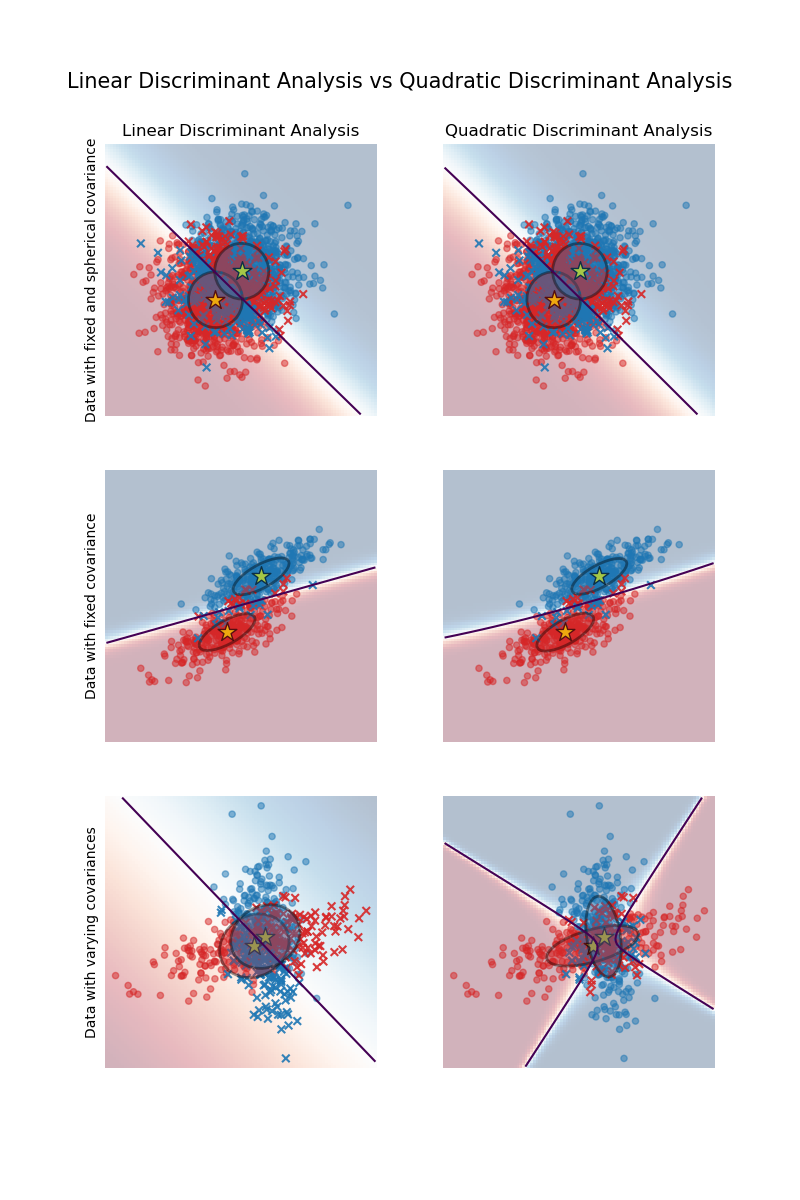{width=30%}


:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt

::: {.content-hidden}
# Bayesian risk class &starf;
:::

In [2]:
#| echo: false
#| output: false
import numpy as np
from numpy.random import multivariate_normal

class BR:
  def __init__(self, omega_all, phi_all, CV_omega, sigma_phi, prior, N = 10**4, print_code = False):
    # all parameters for later use
    self.omega_all = omega_all
    self.phi_all = phi_all
    # No damage parameters
    self.omega_H0 = omega_all[0]
    self.phi_H0 = phi_all[0]
    # Damage parameters
    self.omega_H1 = omega_all[1:]
    self.phi_H1 = phi_all[1:] 
    
    # Coefficient of variation for omega and phi
    self.CV_omega = CV_omega
    self.sigma_phi = sigma_phi

    # number of Monte Carlo samples
    self.N = N
    
    # prior probabilities for theta
    self.prior = prior

    # print code
    self.print_code = print_code


  # def feature_vector(self, features_vector):

  #   return 

  # Statical parameters for the multivariate normal distribution 
  def covariance_matrix(self, S):
    # Sensor vector
    S = np.array(S)

    # Standard deviation
    sigma_omega = self.CV_omega * self.omega_H0 
    sigma_phi = self.sigma_phi * np.ones(self.phi_H0.shape[0]) 

    # modal observability
    mo = np.array([np.linalg.norm(np.multiply(S, phi_i)) for phi_i in self.phi_H0])

    # Variance Omega
    var_omega = sigma_omega**2 / (mo**2)

    # Variance Phi
    var_phi = sigma_phi**2 / (mo**2)

    # Diagonal covariance matrix
    # mu = np.concatenate([self.omega_H0, self.mask_and_normalize(self.phi_H0, S).flatten()])  # mean vector
    mu = self.mu_vector(self.omega_H0, self.phi_H0, S) # mean vector
    diagonal = np.concatenate([var_omega, np.repeat(var_phi, np.sum(S, dtype=int))])  # variances for omega and phi
    cov = np.diag(diagonal)  # covariance matrix
    
    # save for later use
    self.mu = mu
    self.cov = cov 
  
  def mu_vector(self, omega, phi, S):
    # Sensor vector
    S = np.array(S)
    # mean vector 
    mu = np.concatenate([omega, self.mask_and_normalize(phi, S).flatten()])  # mean vector
  
    return mu

  def mask_and_normalize(self,X, S):
    mask = S == 1

    # Step 1: apply mask on last axis
    filtered = X[..., mask]

    # Step 2: compute max along last axis
    max_vals = np.max(np.abs(filtered), axis=-1, keepdims=True)

    # Step 3: avoid division by zero
    max_vals[max_vals == 0] = 1

    # Step 4: normalize
    return filtered / max_vals


  def MCS_modal(self, S, prior_Importance = None):
    # S is the sensor vector
    S = np.array(S)

    # get covariance matrix and mean vector
    self.covariance_matrix(S)

    if prior_Importance is not None:
      # Imoportance sampling for structural states: theta ~ Q(theta) where Q is the importance distribution
      states = np.random.choice(range(len(self.prior)), size=self.N, p=prior_Importance)
      H_vec = (states > 0).astype(int)  # 0 if state == 0, else 1
      self.states = states
      self.H_vec = H_vec

    elif prior_Importance is None:
      # Generate all states and H labels at once: theta ~ P(theta)
      states = np.random.choice(range(len(self.prior)), size=self.N, p=self.prior)
      H_vec = (states > 0).astype(int)  # 0 if state == 0, else 1
      self.states = states
      self.H_vec = H_vec

    # generate errors for omega and phi
    # errors = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)

    # model properties 
    # lambda_star = np.random.multivariate_normal(mean=self.mu, cov=self.cov, size=self.N)
    lambda_star = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)
    lambda_star[:, :len(self.omega_H0)] += self.omega_all[states]
    lambda_star[:, len(self.omega_H0):] += self.mask_and_normalize(self.phi_all[states], S).reshape(self.N, -1)
    self.lambda_star = lambda_star

    # extract omega and phi from lambda_star
    omega_bar = lambda_star[:, :self.omega_H0.shape[0]]
    # phi_bar = lambda_star[:, self.omega_H0.shape[0]:]
    phi_bar = lambda_star[:, self.omega_H0.shape[0]:].reshape(self.N, self.phi_H0.shape[0], np.sum(S, dtype=int))
    self.phi_no_norm = phi_bar.copy() # save the non-normalized phi for later use
    # normize phi_bar by  by the maximum absolute value across all samples for each mode
    # normalize each mode-shape vector per sample (along the last axis)
    max_abs = np.max(np.abs(phi_bar), axis=2, keepdims=True)  # shape: (N, N_phi, 1)
    phi_bar = phi_bar / np.where(max_abs == 0, 1, max_abs)
    # phi_bar = self.mask_and_normalize(phi_bar, S)

    self.omega_bar = omega_bar
    self.phi_bar = phi_bar
    

  def MAC(self, phi1, phi2):
    # Compute the Modal Assurance Criterion (MAC) between two mode shapes
    numerator = np.abs(np.dot(phi1, phi2))**2
    denominator = np.dot(phi1, phi1) * np.dot(phi2, phi2)
    return numerator / denominator if denominator != 0 else 0

  def TMAC(self, phi_theta_1, phi_theta_2):
    N_samples = phi_theta_1.shape[0]
    TMAC_matrix = np.zeros((N_samples, N_samples))
    for i in range(N_samples):
        for j in range(N_samples):
            TMAC_matrix[i, j] = self.MAC(phi_theta_1[i], phi_theta_2[j])

    # sum of diagonal of the MAC 
    self.print2("TMAC matrix:\n", TMAC_matrix)  
    TMAC = np.sum(np.diag(TMAC_matrix)) / (N_samples)
    return TMAC
  
  # Modal Flexibility (MF)
  def MF(self, phi_vec, omega_vec):
    # Compute the Modal Flexibility (MF) for a given mode shape and natural frequency
    return sum(np.diag(np.abs(np.dot(phi_vec, phi_vec.T) / (omega_vec**2))))

  def print2(self, *args):
    if self.print_code:
        print(*args)
    

# Plan

## Time Plan

::: panel-tabset

### Gantt Chart

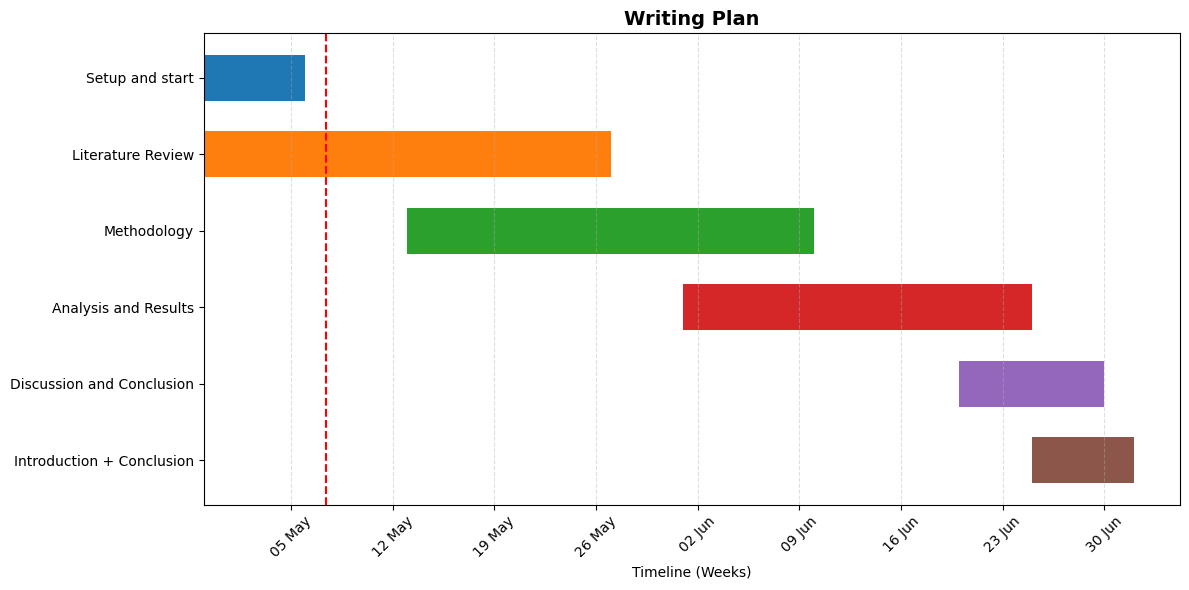

In [3]:
#| echo: false
#| output: false
from python_code.gantt_chart import create_gantt_chart

tasks = [
            ("Setup and start", "2026-04-29", "2026-05-06"),
            ("Literature Review", "2026-04-29", "2026-05-27"),
            ("Methodology", "2026-05-13", "2026-06-10"),
            ("Analysis and Results", "2026-06-01", "2026-06-25"),
            ("Discussion and Conclusion", "2026-06-20", "2026-06-30"),
            ("Introduction + Conclusion", "2026-06-25", "2026-07-02"),
        ]

create_gantt_chart(tasks = tasks, gant_name="Writing Plan")

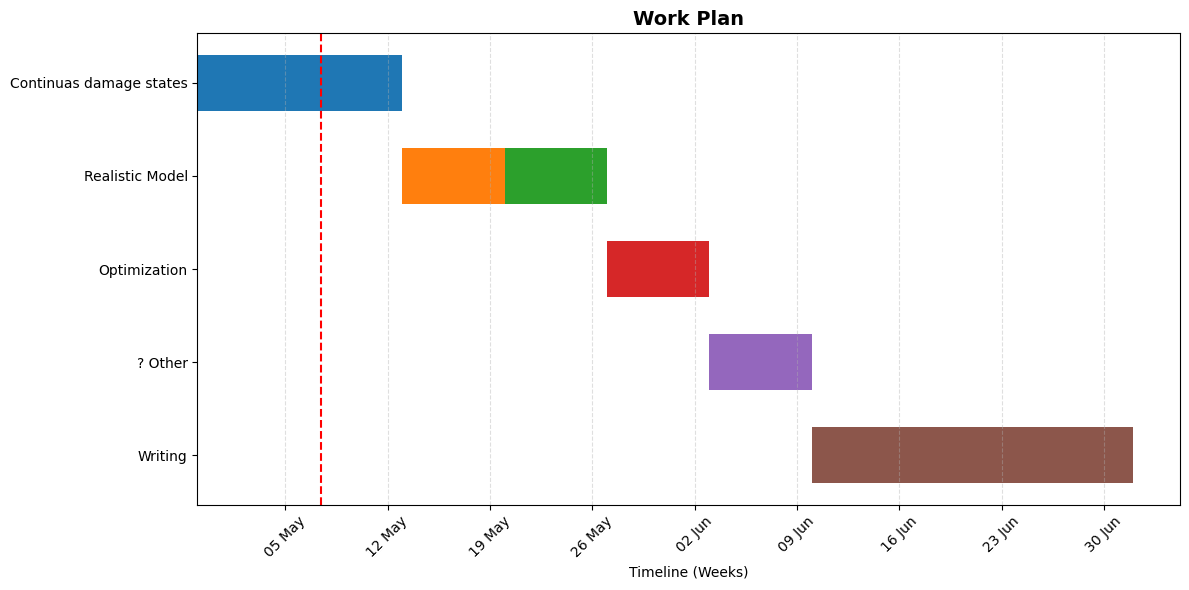

In [4]:
#| echo: false
#| output: true
from python_code.gantt_chart import create_gantt_chart

tasks = [
            ("Continuas damage states", "2026-04-29", "2026-05-13"),
            ("Realistic Model", "2026-05-13", "2026-05-20"),
            ("Realistic Model", "2026-05-20", "2026-05-27"),
            # ("Continuas damage states", "2026-04-29", "2026-05-06"),
            # ("Continuas damage states", "2026-04-29", "2026-05-06"),
            ("Optimization", "2026-05-27", "2026-06-3"),
            ("? Other", "2026-06-3", "2026-06-10"),
            # ("Questions", "2026-05-20", "2026-06-10"),
            ("Writing", "2026-06-10", "2026-07-02"),
        ]

create_gantt_chart(tasks = tasks, gant_name="Work Plan")

### cds. 

**Countinuous damage states**

- Make an funciton for given H1 what is the stiffness reduction factor for the damage state
- Make an rugth function there links the stiffness reduction factor to probability of failure? for the structure
- Use the 2 functions above to update the cost matrix for undetected damage 


### Relaistic model

- Upadate FEM model to an more realistic structure. (2D, more dof's, elments, modes etc.)
- Set up 2-3 cass whit realistic priors and cost matrix
    - read papers and method to set up the priors and cost matrix (Takes time)

### Optimization

- Implement optimization algorithm's to find the optimal decision cretiria for the optimal snosor placements
    - what is the given information ??


### Last 2 weeks

- Ilustative Work on Fream work for testing assumptions? (cut be fun?)
    - Make an sugestion for an surgate model for error in OMA (Not computabol ???)
- Thigtening up the othere work ?
- Comparison with traditional methods 
    - we do not have the samme ground truth to compare with ??? (Not that intresting)




:::

# Stiffness reduction 


## Stiffness reduction effect's

Stiffness reduction factor:
$$
    E_{damaged} = (1 - d) E_{undamaged}
$$

where:

- $E_{damaged}$ is the effective Young's modulus of the damaged structure.
- $E_{undamaged}$ is the Young's modulus of the undamaged structure.
- $d$ is the damage variable, which ranges from 0 (no damage) to 1 (complete failure).

::: {.callout-note title="Static loading"}
Lowering the stiffness leads to:

- $\uparrow \delta$ (higher displacements) and $\uparrow \epsilon$ (higher strains)  (SLS)
- Redistribution of loads in indeterminate systems, to stiffer elements. (ULS)
- $\downarrow P_{cr}$ lower buckling capacity, do to lower stiffness in out of plane buckling. (ULS)
:::

::: {.callout-note title="Dynamic loading"}
Lowering the stiffness leads to:

- $\downarrow \omega$ lower natural frequencies (Resonance effects)
- Large amplitude of the vibrations for the same loading (conservation of energy in equation of motion)
:::

::: {.callout-note title="Note"}
If the stiffness reduction is due to plastic deformations, then the ductility of the structure can be decreased for further loading. This has an effect on:

- Earthquakes where there are large cyclic loading, where the structure rely on ductility to dissipate energy.
:::

::: {.callout-tip title="FEM model for evaluating the effect of stiffness reduction"}
Static loading:

- Linear FEM model: to capture load redistribution in indeterminate systems. (if deformations are small)
- **Nonlinear FEM model**: to capture geometric instability (buckling), and non linear effects (if the deformations are not small.)
    - mostly geometric nonlinearity.

Dynamic loading:

- dynamic linear FEM model: to capture the effect of Modal parameters when the stiffness is reduced. (if deformations are small)
    - This is the case when we do OMA.
- **dynamic nonlinear FEM model**: to capture nonlinear effects, and buckling (if deformations are not small)
    - both matrial Nonlinearity and geometric nonlinearity can be captured in this model.

:::


::: {.notes}
Strain-controlled failure:

- Ultimate compressive strain capacity of concrete
- SLS: Serviceability limit states
     - Deflection limits
     - Crack width limits
- Buckling
- Fatigue: Controlled by strain/stress cycles, not single strength value
:::

# Continuous Damage States

## General idea

Probability of level of stiffness reduction:
$$
    P(\delta E \mid \theta)
$$

where: 

- $\delta E$ is the stiffness reduction factor

Probability of failure given damage state add stiffness reduction factor:
$$
P(\text{failure} \mid \delta E, \theta)
$$



::: {.callout-note title="Boundary conditions: stiffness reduction factor"}
No damage leads to no stiffness reduction:
$$
P(\delta E > 0 \mid \theta = \text{No damage}) = 0, \quad P(\delta E = 0 \mid \theta = \text{No damage}) =1
$$

Probability mass for damage state:
$$
 P(\delta E > 0\mid \theta = \text{damage}) = \int_0^1 P(\delta E \mid \theta = \text{damage}) d\delta E = 1
$$
:::



## Probability of level of stiffness reduction

$$
    P(\delta E \mid \theta)
$$

This is an function where we have no good way to estimate it, but we can make some assumptions about the shape of the function.

**Assumptions:**

1. The probability of stiffness reduction of close to 100% is very low? 
2. The probability of stiffness reduction of close to 0% is low?
     - Argument 1: There is no value of upserving small martrial degradations, even if they are present, they are only valuable if they leed to faster degradations there will have an effect on the probability of failure.
     - Argument 2: the prior are constructed on the basis of $H_1$ being that the structure is damaged, (If damage is defined as an stiffness change there leads to a significant change of probability of failure. )


## Probability of failure given stiffness reduction

$$
P(\text{failure} \mid \delta E, \theta) = P(g(X) < 0 \mid \delta E, \theta)
$$


variables:
$$
X = \{\delta E, \theta, F, f_y, \epsilon_{ult}, ...\}
$$

- $\delta E$ is the stiffness reduction factor
- $\theta$ is the damage state vector
- $F$ is the applied load
- $f_y$ is the yield strength of the steel
- $\epsilon_{ult}$ is the ultimate strain capacity of forexample the concrete

::: {.callout-note title="Note"}
- $\delta E$ is not an stochastic variable 
- $\theta$ is not an stochastic variable
- all the other variables are stochastic variables.
:::

limit state function:
$$
g(X)=R(X)−S(X)
$$

where:

- $R(X)$ is the resistance  / the capacity of the structure.
- $S(X)$ is the load effect / the response of the structure to the applied load
- Failure occurs when $g(X) < 0$

::: {.callout-note title="Clarification"}
This is a note that will appear as a colored box in your PDF.
:::


## Limit state function

![](presentation_data/img/P_failure.png)

## My expectations of the probability of failure

Relationship between stiffness reduction and probability of failure:

- $\downarrow \delta E \rightarrow \downarrow P_{cr}$: Liniar relationship in Static loading whit no redistribution of loads ($P_{cr} \propto E I$)
    - Eurlerar buckling formula: $P_{cr} = \frac{\pi^2 E I_z}{(K L)^2}$
        - $K$ is the effective length factor


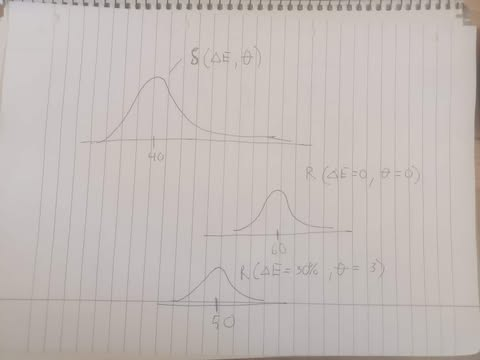

::: {.notes}
Eurlerar buckling:

if the 

:::

## Probability functions 

I am intrested in probability distributions in the interval [0,1].

- [Beta distribution](https://en.wikipedia.org/wiki/Beta_distribution), [np.random.beta](https://numpy.org/doc/stable/reference/random/generated/numpy.random.beta.html#numpy.random.beta), [scipy.stats.beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html#scipy.stats.beta)

Beta PDF:
$$
f(x; \alpha, \beta) = \frac{x^{\alpha-1} (1-x)^{\beta-1}}{B(\alpha, \beta)}
$$

where:

- $\beta$ is the beta function, defined as $B(\alpha, \beta) = \frac{\Gamma(\alpha) \Gamma(\beta)}{\Gamma(\alpha + \beta)}$
- $\Gamma$ is the gamma function.

Stiffness reduction probability distribution: 

- $a = 4$ and $b= 4$ (symmetric, mean = 0.5, low probability at tails)
- $a = 4$ and $b= 10$ (mean < 0.5, low probability at tails)

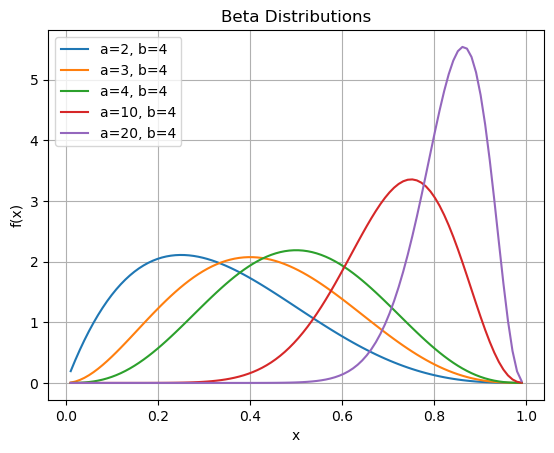

In [5]:
#| echo: false
#| output: true
from scipy.stats import beta

error = 0.01
error = 0.01
x = np.linspace(0+error, 1-error, 100)

a_list = [2,3,  4, 10, 20]

for a in a_list:
    b = 4
    y = beta.pdf(x, a=a, b=b)
    plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Beta Distributions')
plt.legend([f'a={a}, b={b}' for a, b in zip(a_list, np.ones_like(a_list)*b)])
plt.grid()
plt.show()


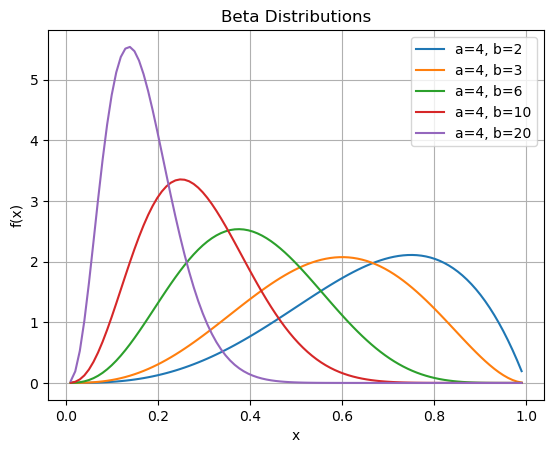

In [6]:
#| echo: false
#| output: true
from scipy.stats import beta

error = 0.01
error = 0.01
x = np.linspace(0+error, 1-error, 100)

b_list = [2, 3, 6, 10, 20]

for b in b_list:
    a = 4
    y = beta.pdf(x, a=a, b=b)
    plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Beta Distributions')
plt.legend([f'a={a}, b={b}' for a, b in zip(np.ones_like(b_list)*a, b_list)])
plt.grid()
plt.show()

## Problem whit continuous damage states

::: {.callout-note title="Problem 1"}
Eigen value problem: 
$$
(K(\theta, \delta E) - \omega^2 M) \phi = 0
$$

- $\omega$ is the natural frequency, eigen values
- $\phi$ is the mode shape, eigen vectors 
- $K$ is the stiffness matrix
    - the static loading is also included in the stiffness matrix ??? 
- $M$ is the mass matrix

For the cantilever beam dos $10^4$ evaluations of the eigen value problem take 32s on my PC. 

Problem:

- It is some what expensive to evalueta the omega and phi for each evaluation

Solution 1: 

- Build an surrogate model of the modal prameters given the siffness reduction factor, and the damage state. 
    - Problem 1: the cost of building the surrogate model, increases fast whit the number of posibole damage states $\theta$.
    - Problem 2: For my structure is the relationship cose to linear, but i think that for more complex structures is the relationship not always close to linear.
    - Problem 3: changing of the order of modes and mode shapes, when the stiffness is reduced, can lead to problems with the surrogate model.

Solution 2:

- Use the Build FEM model maby it is fast enough

Sulution 3:

- Extract stiffness and mass matrices form the model and try to build an faster solver? 

:::

In [7]:
#| echo: true
#| output: true
import math as math
n = 10**3 # number of elements
k = 3 # size of combinations 

math.factorial(n) / (math.factorial(k) * math.factorial(n-k))

166167000.0

## Example for understanding

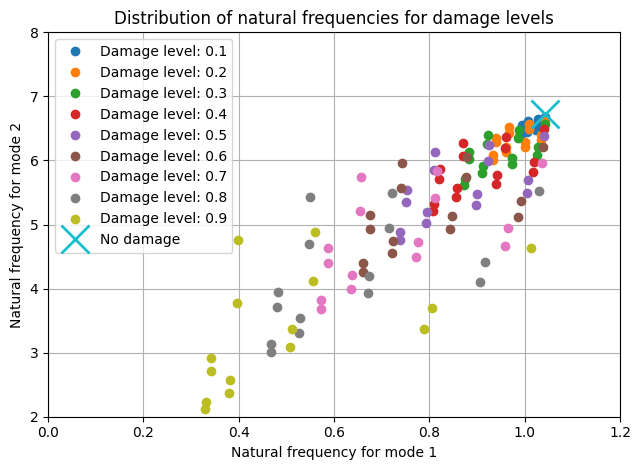{width=50%}

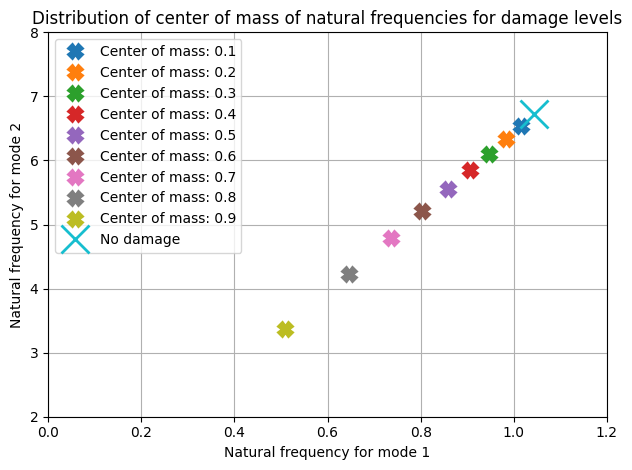{width=50%}

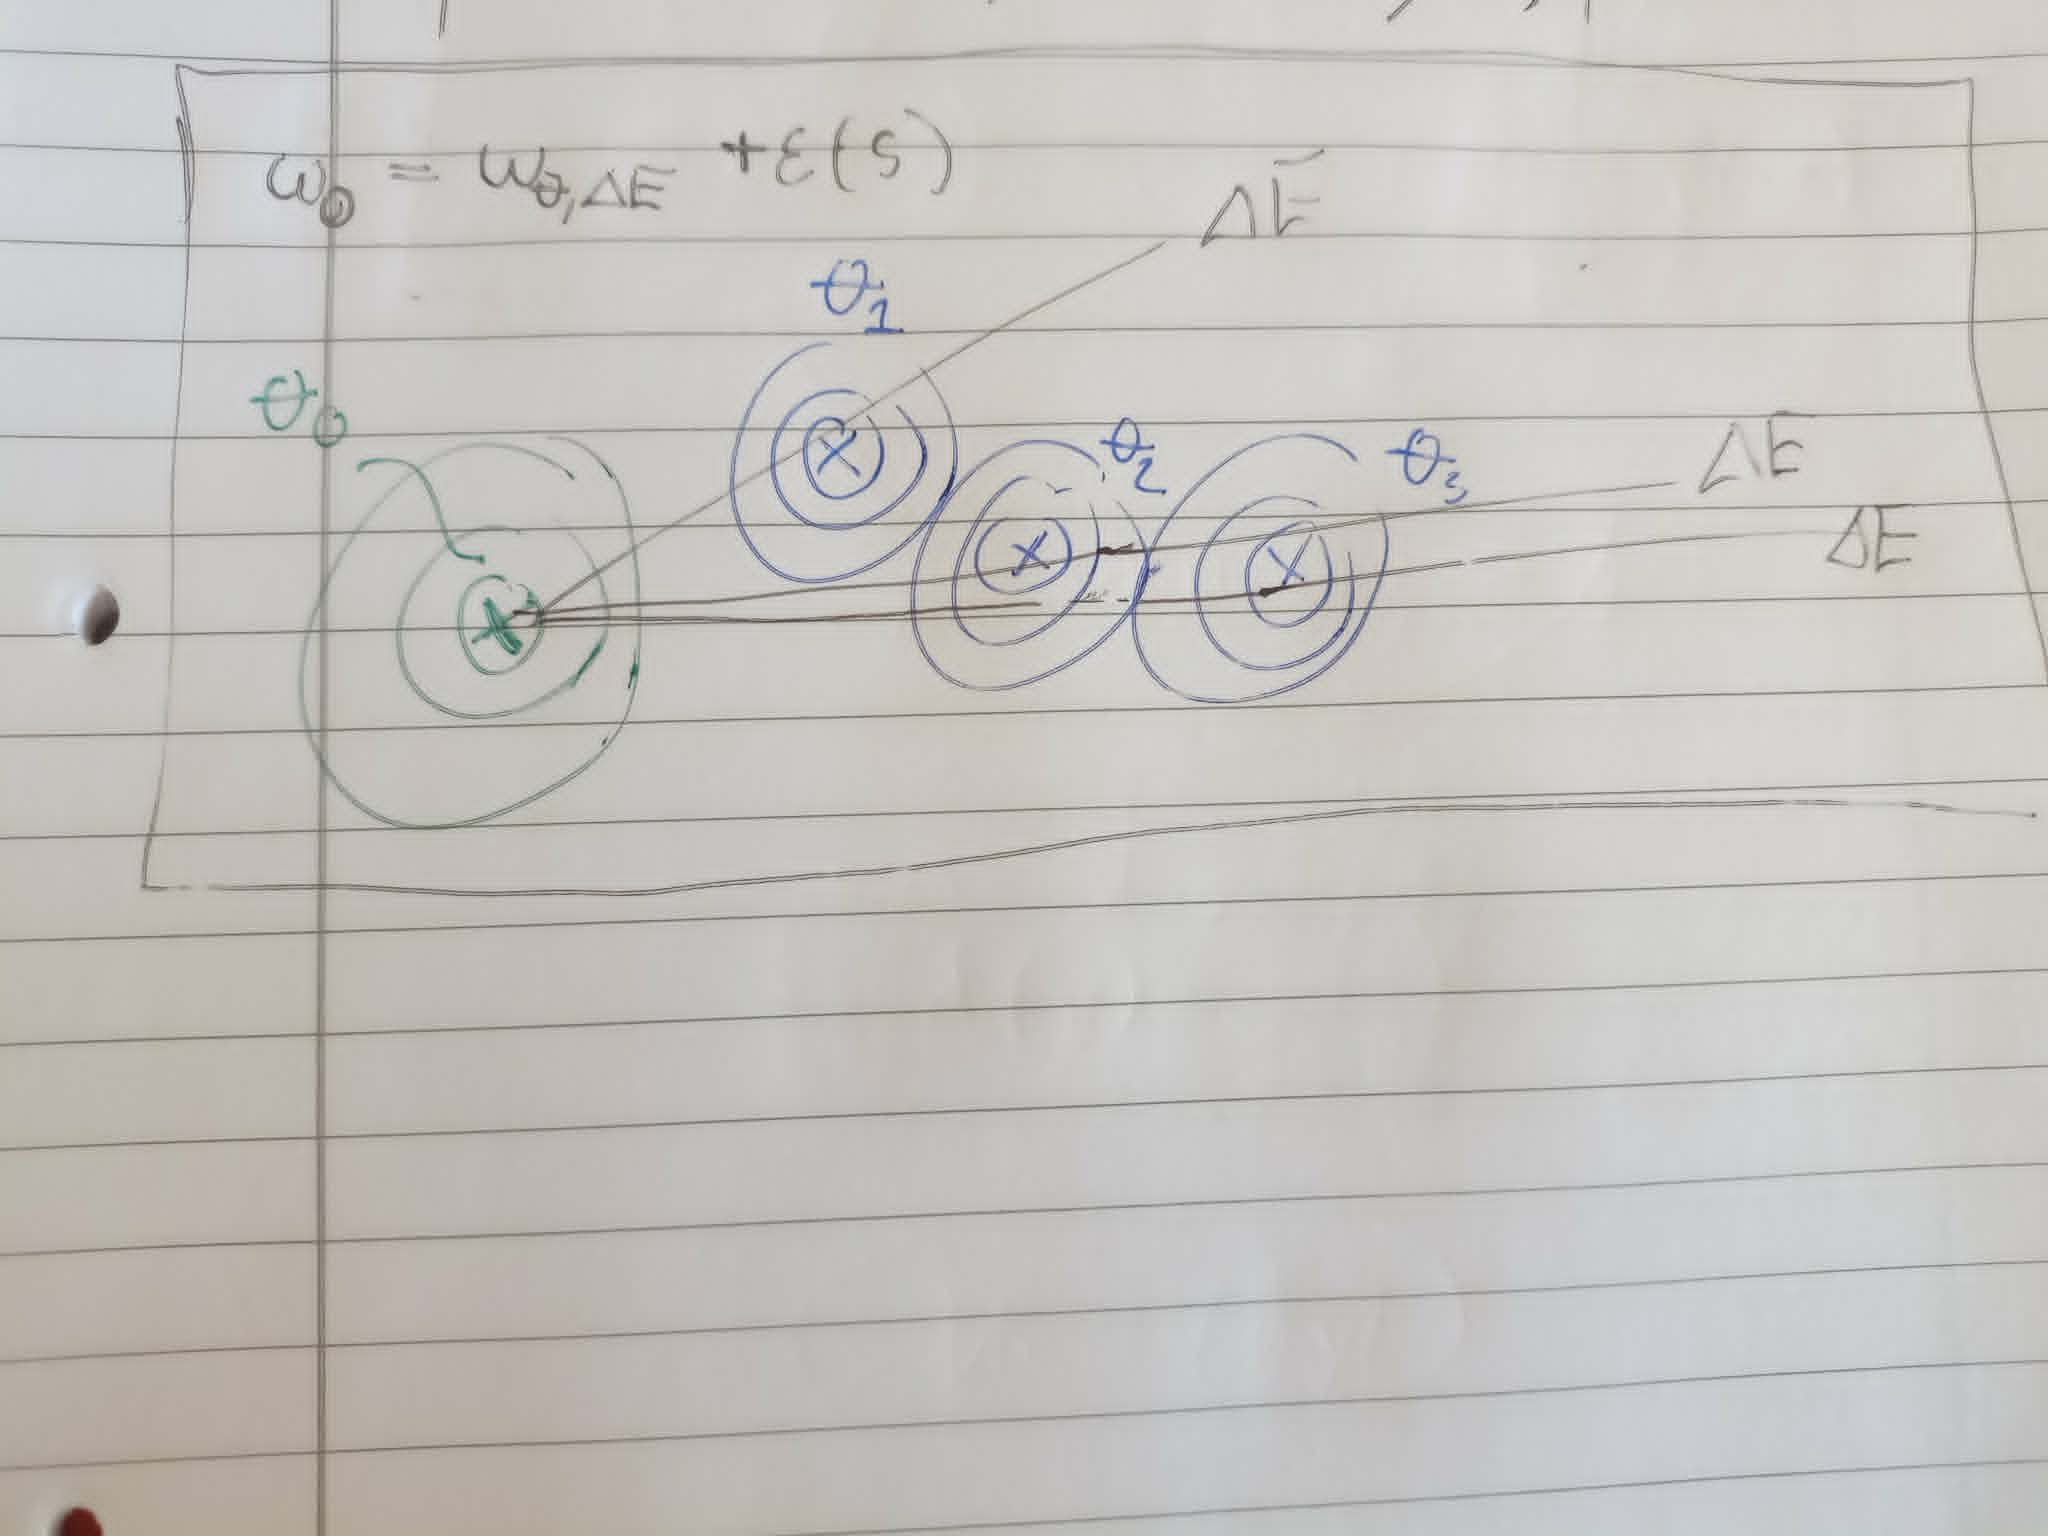{width=50%}

- $\omega_1$ for the first axis
- $\omega_2$ for the second axis

Stochastic modal parameters: 


$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim p(\boldsymbol\omega, \boldsymbol\phi \mid \theta)
$$

$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim g(\theta, e) + \epsilon(\theta, e)
$$

Where: 

- $g(\theta, e)$ is the deterministic part of the model, which depends on the structural state $\theta$ and the sensor configuration $e$.
- $\epsilon(\theta, e)  = \epsilon_0(\cdot) + ... + \epsilon_n(\cdot)$

Likelihood for the Level 1 SHM system:

$$
f(y \mid H_i)= \sum_{\theta \in H_i} \int f(y, \theta, \delta E \mid H_i) d\delta E =\sum_{\theta \in H_i} \int f(y \mid \theta, \delta E) P(\theta \mid H_i) f(\delta E|\theta) \, d\delta E
$$

Posterior distribution (level 1 SHM system):

$$
P(H_i \mid y) = \frac{f(y \mid H_i) P(H_i)}{f(y)}
$$

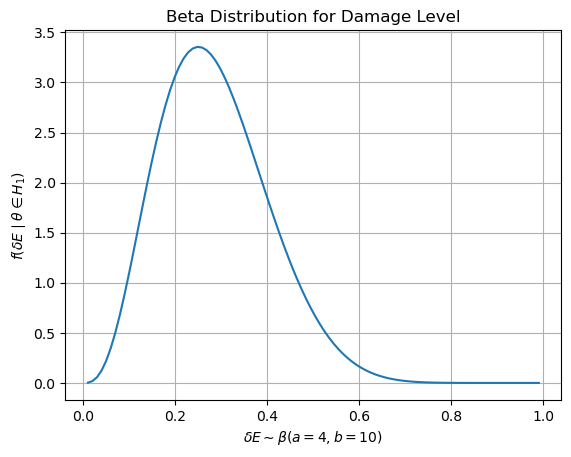

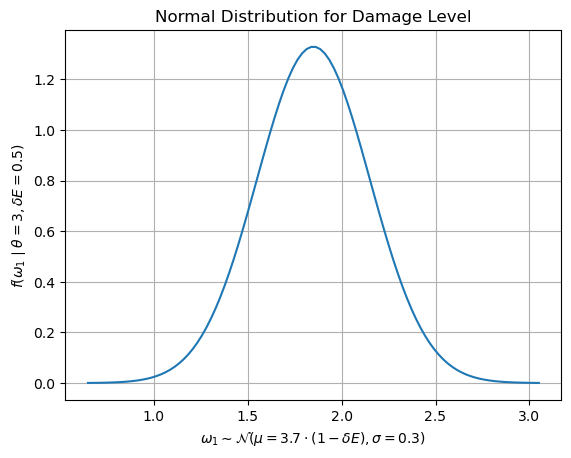

In [8]:
#| echo: false
#| output: true
from scipy.stats import beta 
from scipy.stats import norm

x = np.linspace(0+error, 1-error, 100)

a = 4
b = 10
y = beta.pdf(x, a=a, b=b)
plt.plot(x, y)
plt.ylabel(r'$f(\delta E \mid \theta \in H_1)$')
plt.xlabel(r'$\delta E \sim \beta(a=4, b=10)$')
plt.title('Beta Distribution for Damage Level')
plt.grid()
plt.show()

delta_E = 0.5
mu = 3.7 * (1 - delta_E)
sigma= 0.3
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, loc=mu, scale=sigma)
plt.plot(x, y)
plt.ylabel(rf'$f(\omega_1 \mid \theta = 3, \delta E = {delta_E} )$')
plt.xlabel(r'$\omega_1 \sim \mathcal{N}(\mu=3.7 \cdot (1- \delta E), \sigma=0.3)$')
plt.title('Normal Distribution for Damage Level')
plt.grid()
plt.show()



Joint distribution of $\omega_1$ and $\delta E$ given the damage state $\theta$:

$$
  f_{\omega_1}(\omega_1, \delta E|\theta) =  f_{\omega_1}(\omega_1 \mid \theta, \delta E)f_{\delta E}(\delta E|\theta)
$$

Marginal distribution of $\omega_1$ given the damage state $\theta$:
$$
f_{\omega_1}(\omega_1 \mid \theta) = \int f_{\omega_1}(\omega_1 \mid \theta, \delta E)f_{\delta E}(\delta E|\theta) d\delta E
$$

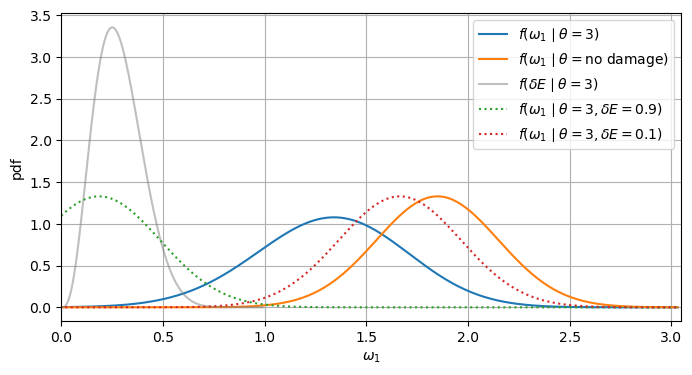

In [9]:
#| echo: false
#| output: true

# Numerical marginal p(omega1 | theta) by integrating out deltaE
# uses existing variables: BRinf, CV_omega, beta, norm, error

# grid for deltaE
delta = np.linspace(error, 1-error, 300)
a, b = 4, 10  # beta parameters chosen earlier
pdf_delta = beta.pdf(delta, a=a, b=b)

# conditional mean & std for omega1 given deltaE (simple model: omega scales with (1-deltaE))
mu0 = mu              # undamaged first natural frequency
mu_delta = mu0 * (1 - delta)
sigma_delta = np.ones_like(delta) * sigma      # CV-based std

# omega grid for plotting
minw = np.min(mu_delta - 4*sigma_delta)
maxw = np.max(mu_delta + 4*sigma_delta)
omega_grid = np.linspace(minw, maxw, 400)

# compute marginal: f(omega) = \int f(omega | delta) f_delta(delta) ddelta
# shape: norm.pdf -> (len(omega_grid), len(delta))
cond_pdf = norm.pdf(omega_grid[:, None], loc=mu_delta[None, :], scale=sigma_delta[None, :])
integrand = cond_pdf * pdf_delta[None, :]
f_marginal_damage = np.trapezoid(integrand, delta, axis=1)

# H0 (no damage): deltaE = 0 w.p.1 -> conditional is the marginal
f_H0 = norm.pdf(omega_grid, loc=mu0, scale=sigma)

# plot results
plt.figure(figsize=(8,4))
plt.plot(omega_grid, f_marginal_damage, label=r'$f(\omega_1\mid \theta= 3)$')
plt.plot(omega_grid, f_H0, label=r'$f(\omega_1\mid \theta=\text{no damage})$')
# plot deltaE distribution for reference
# plt.twinx()
plt.plot(delta, pdf_delta, color='gray', alpha=0.5, label=r'$f(\delta E \mid \theta=3)$')
plt.xlim(0, mu0 + 4*sigma)

# plot f(omega_1, deltaE = 0.9 | theta=3) for reference
delta_ref = 0.9
mu_ref = mu0 * (1 - delta_ref)
sigma_ref = sigma
y_ref = norm.pdf(omega_grid, loc=mu_ref, scale=sigma_ref)
plt.plot(omega_grid, y_ref, ':', label=r'$f(\omega_1 \mid \theta=3, \delta E = 0.9)$')
# plot f(omega_1, deltaE = 0.1 | theta=3) for reference
delta_ref2 = 0.1
mu_ref2 = mu0 * (1 - delta_ref2)
sigma_ref2 = sigma
y_ref2 = norm.pdf(omega_grid, loc=mu_ref2, scale=sigma_ref2)
plt.plot(omega_grid, y_ref2, ':', label=r'$f(\omega_1 \mid \theta=3, \delta E = 0.1)$')

plt.xlabel(r'$\omega_1$')
plt.ylabel('pdf')
plt.legend()
plt.grid(True)
plt.show()


::: {.callout-note title="Note for plot"}
- this is only an ilustration of one damage state $\theta = 3$.
:::

# Nice Book

## Structural Reliability Analysis and Prediction

- Se table 2.5 to 2.8. “Acceptable Risk Criterion” ([“Structural Reliability Analysis and Prediction”, 2017, p. 50](zotero://select/library/items/WAR7AJ3L)) ([pdf](zotero://open-pdf/library/items/YBLST87B?page=69&annotation=GSQIE3DG)) (Can be used to formulate priors, and cost matrix)

# Questions ? 

## Work plan

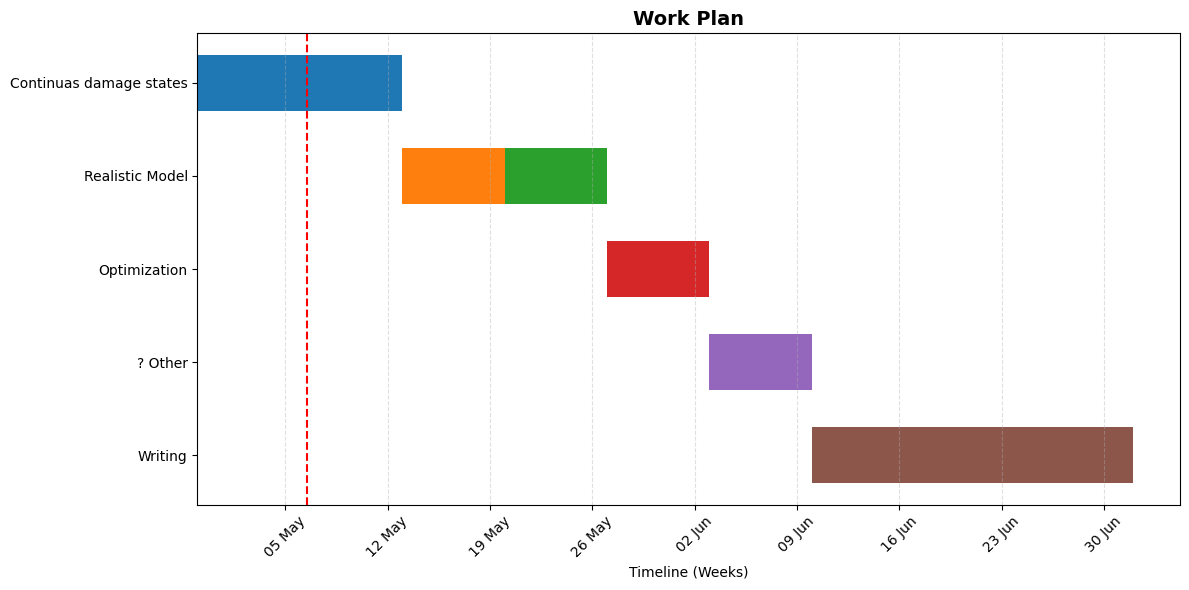

- Am i missing something important in the work plan ?
- Is it oaky that i dont do comparison with traditional methods ? (it is form the procject plan)

## Other

- good ideas for building an surrogate model for the mapping $\Delta E$ to the modal parameters ?
- good ideas for seting up the ralationship between the stiffness reduction factor and the probability of failure ? 
- what do you think about the stiffness reduction function? 

Note: 

- can you send the bridge model so i can see it? 

## Idear's

Train the covariance matrix on the modal data, so i don't need to know the parameters for the covariance matrix in the OMA error function? 

# Meting 2 (14/07)

Overview of last weeks meting:

- Understanding of what stiffness reduction effect's (static and dynamic loading).
- Understanding of how to compute the probability of failure.
- Presentation of curent problems and ideas for solving them.

Note: new procject name and disription

::: {.notes}
- evangolos suggested nice companyes there use reliability analysis and probability's
:::

## Presentation overview

- Generate data with an continuous stiffness reduction factor, and damage state. **(Step 1)**
    - Set up
        - FEM model
        - Priors $\theta, H$ 
        - distribution of the stiffness reduction factor
    - What covariance matrix to use? given e sensor configuration, and damage state? 
- Calculate features **(Step 2)**
    - $y = [\omega_1, ... , \omega_n, MAC_{1,1}, ... , MAC_{n,n}, TMAC, MF]$ 
    - print features
- Feature selection and dimensionality reduction **(Step 3)**
    - Feature selection
    - Feature selection with the inclustion of cunsequences (cost matrix)
        - Asumme link between stiffness reduction factor and probability of failure.
- Training of decision model **(Step 4)**
    - Train and Test (80/20)
        - Gaussian Mixture Model (GMM)
        - Logistic regression
    - Evaluation of decision model
        - Bayesian risk
        - ROC curves
        - [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix)
- Make full case study with the decision models **(Step 5)**

# FEM model

In [10]:
from python_code.FEM_class import FEM_class
# clear previous OpenSees model
# ops.wipe()

import numpy as np
import openseespy.opensees as ops


Running: build_model()
Creating node 1 at (0.0, 0.0)
Creating node 2 at (0.0, 5.0)
Creating node 3 at (0.0, 10.0)
Creating node 4 at (0.0, 15.0)
Creating node 5 at (0.0, 20.0)
Applying boundary condition at node 1: fix_x=1, fix_y=1, fix_rotation=1
Creating element 1 between nodes 1 and 2 with material 0
Creating element 2 between nodes 2 and 3 with material 0
Creating element 3 between nodes 3 and 4 with material 0
Creating element 4 between nodes 4 and 5 with material 0
Assigning mass of 1000.0 kg to node 2.0
Assigning mass of 1000.0 kg to node 3.0
Assigning mass of 1000.0 kg to node 4.0
Assigning mass of 1000.0 kg to node 5.0


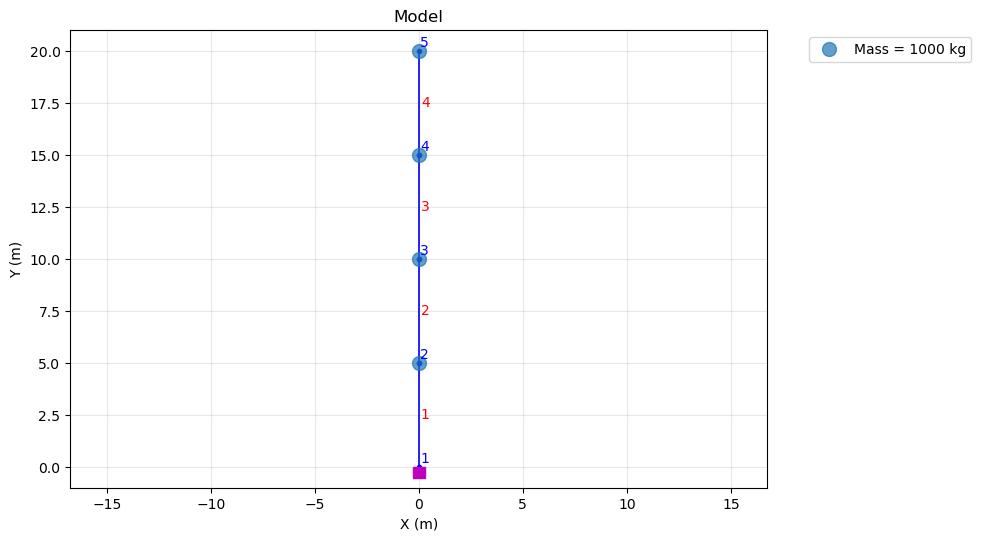

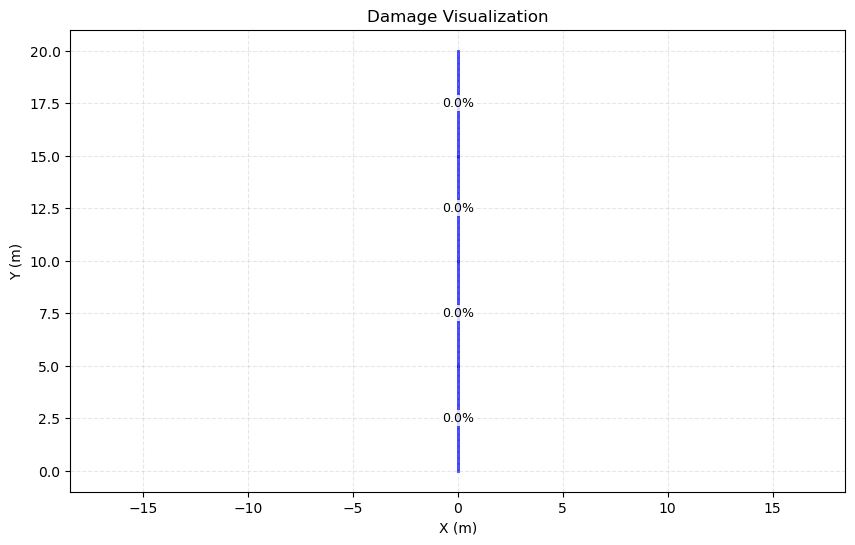


Running: gravity_analysis()
    !Error in applying element loads: iteration over a 0-d array
Applying nodal load of (0.0, -9810.0, 0.0) N to node 2.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 3.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 4.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 5.0
Using sfac = 8.563e+03


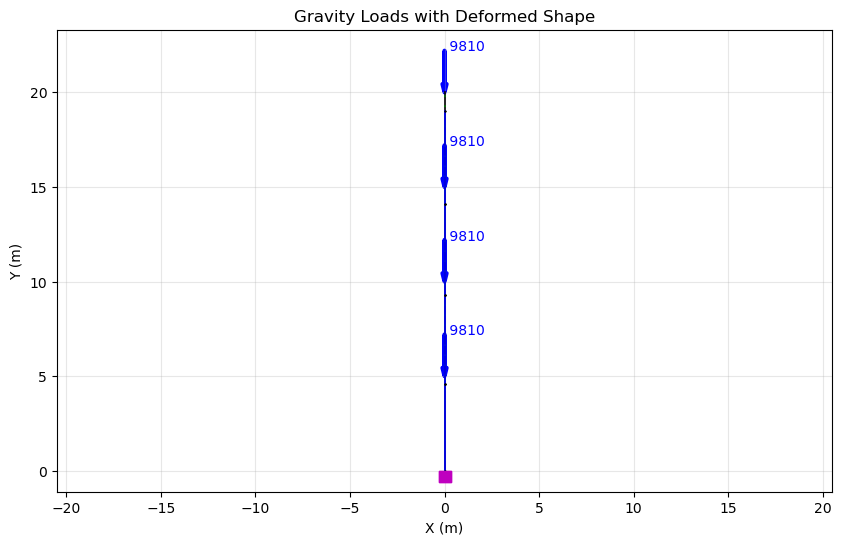

-----------------gravity analysis successfully run--------------------

Running: get_modal_periods()
Number of modes not specified, using n_modes = 4
Mode 1 - period T1 = 0.958 seconds
       - modal participation factor (X direction) = 69.6273
Mode 2 - period T2 = 0.149 seconds
       - modal participation factor (X direction) = 21.0241
Mode 3 - period T3 = 0.053 seconds
       - modal participation factor (X direction) = 6.9392
Mode 4 - period T4 = 0.029 seconds
       - modal participation factor (X direction) = 2.4024


WARNING - the 'fullGenLapack' eigen solver is VERY SLOW. Consider using the default eigen solver.Using DomainModalProperties - Developed by: Massimo Petracca, Guido Camata, ASDEA Software Technology


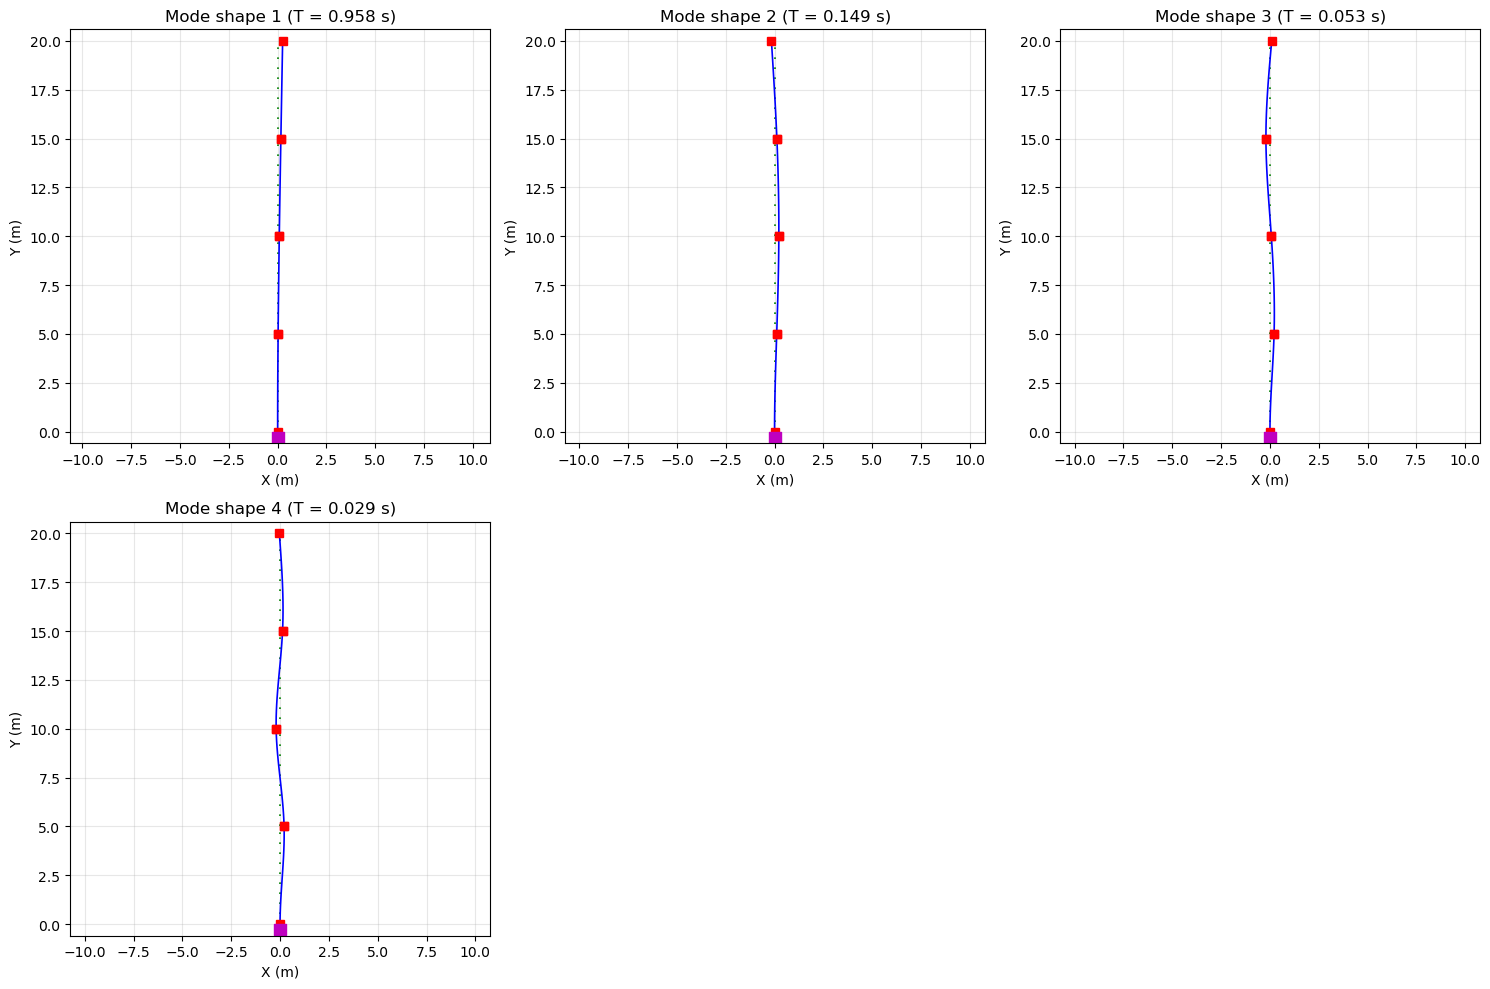

Modal periods (s): [0.95816562 0.14876015 0.0526906  0.02924239]
Modal frequencies (Hz): [ 1.04366091  6.72223044 18.97871864 34.1969293 ]
Modal frequencies (rad/s): [  6.55751487  42.23701954 119.24680614 214.86564374]


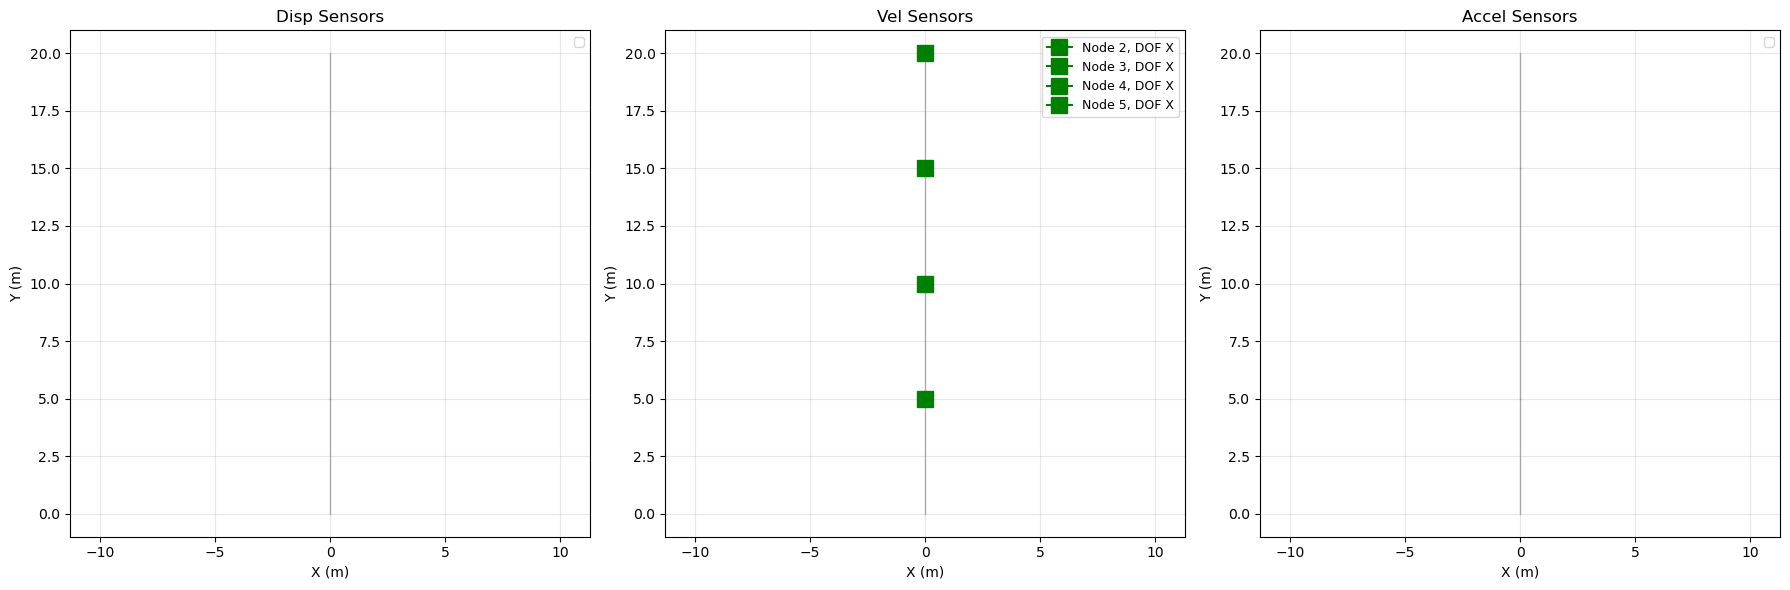

In [11]:
# x, y coordinates of nodes
X = [
    [0,0],
    [0,5],
    [0,10],
    [0,15],
    [0, 20]
]

# node_i, node_j, material_property_index
IX = [
    [0,1,0],
    [1,2,0], # beam = 1
    [2,3,0],
    [3,4,0]
]

# E, A, I, rho
mprop = [
    # E,     A,    I,     rho
    # [210e9, 0.01, 8.3e-6, 7850], # column
    [210e9, 0.02, 8.3e-4, 7850]  # beam

]

# nodal masses: node_id, mass (kg)
nodeMass = [
    [1, 1000], 
    [2, 1000], 
    [3, 1000],
    [4, 1000]
]


# element loads: element_id, load (N/m),    - load is in the negative y direction (gravity load)
# elementLoad = [
#     [1, -1000]
# ]
elementLoad = None

# nodal loads: node_id, load_x, load_y, load_z
nodeLoad = [
    [1, 0, -1000*9.81, 0], 
    [2, 0, -1000*9.81, 0], 
    [3, 0, -1000*9.81, 0], 
    [4, 0, -1000*9.81, 0],

]
# nodeLoad = None


# node_id, fix_x, fix_y, fix_rotation
bounds = [
    [0,1,1,1],
]

### setup model
# model = SHMStructure(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=False, plot_code=False)
# FEM = FEM_class(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=True, plot_code=False)
FEM = FEM_class(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=True, plot_code=True)

## Stiffness reduction
# model.set_damage(elem_ids=[0], level=0.01)
# model.set_damage(elem_ids=[1], level=0.2)
# model.set_damage(elem_ids=[2], level=0.4)

# add ground motion data
filename = 'data/ambient_excitation_10min.npz'
data = np.load(filename)
dt = data['dt']
acc_filtered = data['acc']
FEM.add_ground_motion(acc_filtered, dt, load_factor=40)



## Build the model
# model.build_model(plot_code=True)
FEM.build_model(plot_code=False) 
FEM.plot_damage()

## Run gravity analysis
# model.gravity_analysis(n_steps=10, plot_code=True)
FEM.gravity_analysis(n_steps=10, plot_code=False)


## Run dynamic analysis with ground motion
FEM.get_modal_periods()
print("Modal periods (s):", FEM.modal_periods)
print("Modal frequencies (Hz):", 1/np.array(FEM.modal_periods))
print("Modal frequencies (rad/s):", 2*np.pi/np.array(FEM.modal_periods))

# plot sensor locations on the structure


# add sensors
# dof: 0=x, 1=y, 2=rotation
# type: 0=disp, 1=vel, 2=acc
# FEM.add_sensor(node=0, dof=0, type=2)
FEM.add_sensor(node=1, dof=0, type=1) 
FEM.add_sensor(node=2, dof=0, type=1) 
FEM.add_sensor(node=3, dof=0, type=1) 
FEM.add_sensor(node=4, dof=0, type=1) 

FEM.plot_sensors_on_structure()


## Geometry 

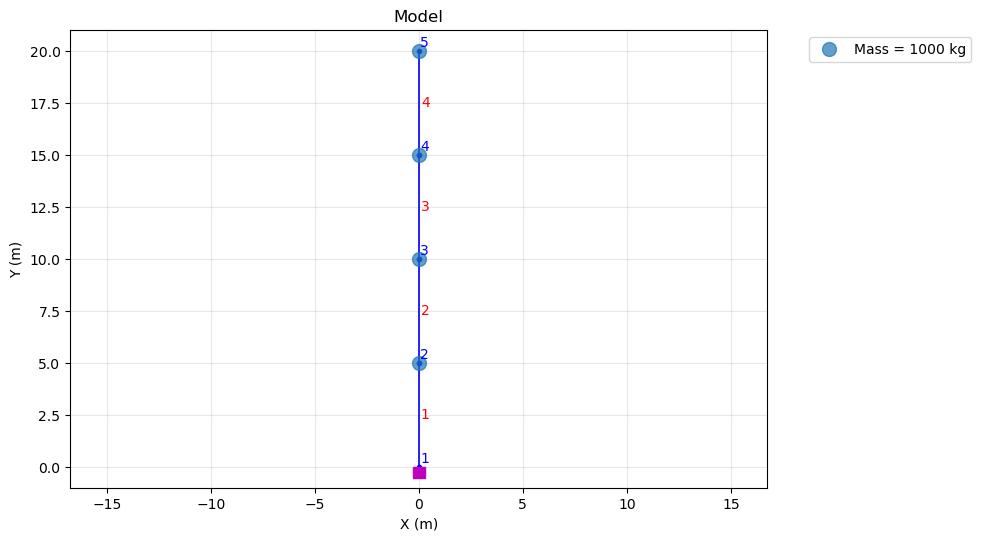

In [12]:
#| output: True
FEM.plot_model()


## Mode Shapes

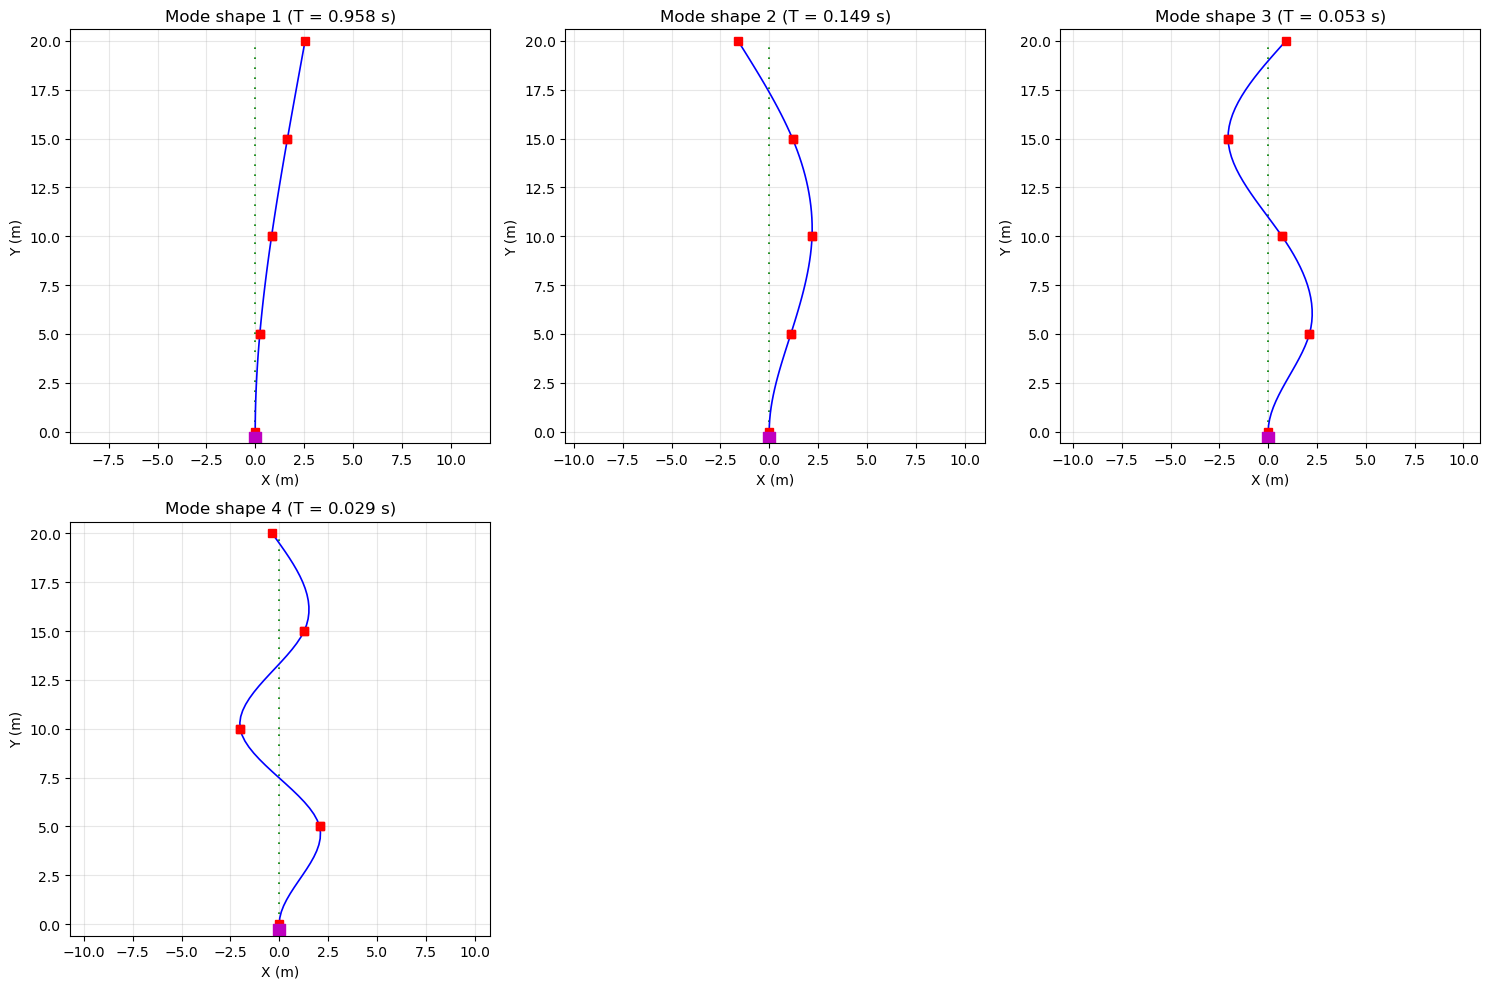

In [13]:
#| output: True

# plot the first 4 mode shapes for the undamaged and damaged cases
FEM.plot_mode_shapes(n_modes=4, scale = 10)

## Damaged scenarios

In [14]:
from python_code.OMA_class import OMA_class
OMA = OMA_class(print_code=False, plot_code=False)

for i in range(2):
    OMA.extract_all_feature_cases(FEM, damage_level=0.5, name="damage_scenarios.npz", save_to_file=False)

# 10**4 evalutions take 32s on my PC with

OMA.true_natural_frequencies, OMA.true_mode_shapes

([array([ 1.04366091,  6.72223044, 18.97871864, 34.1969293 ]),
  array([ 1.04016946,  6.37408214, 16.94141413, 32.69718732]),
  array([ 1.00798185,  5.70080569, 17.35875549, 30.8807843 ]),
  array([ 1.00473399,  5.49341868, 15.90808363, 29.88390605]),
  array([ 0.92507043,  6.23371597, 17.46866929, 29.94624496]),
  array([ 0.92258776,  5.98730864, 15.53564471, 28.45986456]),
  array([ 0.89964709,  5.47467477, 15.84453593, 27.52478695]),
  array([ 0.89730897,  5.30595967, 14.55257746, 26.51025891]),
  array([ 0.81195442,  6.13035947, 17.10851368, 31.24638691]),
  array([ 0.8103798 ,  5.84807262, 15.44423139, 29.33255978]),
  array([ 0.79530858,  5.19322953, 15.73551334, 27.80517814]),
  array([ 0.79379421,  5.01930311, 14.58691439, 26.49373766]),
  array([ 0.75271929,  5.54133756, 15.97818712, 27.94024187]),
  array([ 0.75143744,  5.35573313, 14.35609552, 26.10050471]),
  array([ 0.73921667,  4.8848373 , 14.48859379, 25.43674128]),
  array([ 0.7379797 ,  4.75333473, 13.41998065, 24.1808

Damage scenarios: 
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 0, 1, 1), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 1, 1, 1), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (1, 1, 1, 1)]
size of theta: 16
Plot of case: (1, 1, 1, 1): 


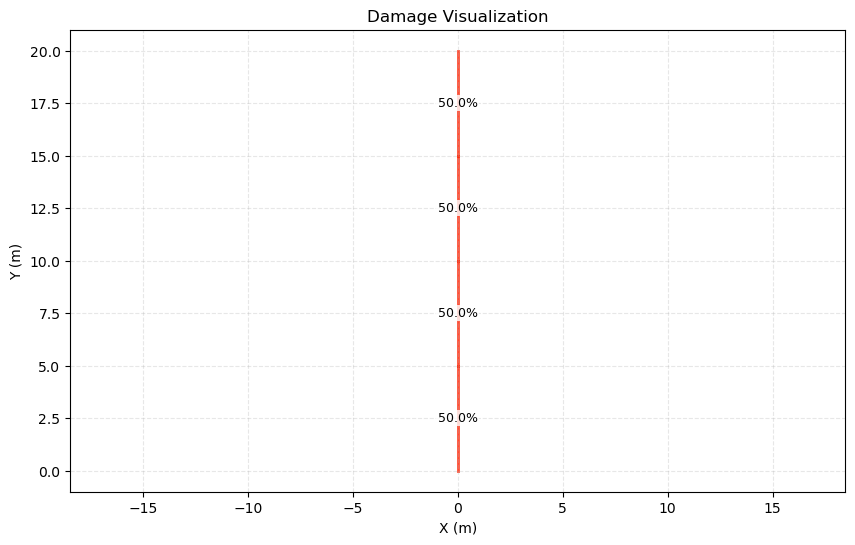

In [15]:
#| output: True

# see the damage scenarios
print(f"Damage scenarios: \n{OMA.theta}")
print(f"size of theta: {len(OMA.theta)}")
print(f"Plot of case: {OMA.theta[-1]}: ")
FEM.plot_damage()


## Sensor configurations

In [16]:
#| echo: true
#| output: true
# nodes  
e_sensor = np.arange(len(X))

# list of fixed nodes
fixed_nodes = [bounds[i][0] for i in range(len(bounds))]

# remove fixed nodes
e_sensor = e_sensor[~np.isin(e_sensor, fixed_nodes)] # ~ is the logical NOT operator, which inverts the boolean array returned by np.isin
print(f"Sensor nodes: {e_sensor}")

# make an list whit all possible combinations of sensor placements
import itertools # generate the solution space of all possible combinations.
# e_configuration = list(itertools.combinations(e_sensor.tolist(), 3))
e_configuration =  np.array(list(itertools.product([0, 1], repeat=len(e_sensor)))) # all combinations of 0 and 1 for each sensor node
e_configuration = e_configuration 
print(f"Number of sensor configurations: {len(e_configuration)}")
for i in range(len(e_configuration)):
    print(f"Configuration {i} given in nodes with sensors: {e_configuration[i]}")

Sensor nodes: [1 2 3 4]
Number of sensor configurations: 16
Configuration 0 given in nodes with sensors: [0 0 0 0]
Configuration 1 given in nodes with sensors: [0 0 0 1]
Configuration 2 given in nodes with sensors: [0 0 1 0]
Configuration 3 given in nodes with sensors: [0 0 1 1]
Configuration 4 given in nodes with sensors: [0 1 0 0]
Configuration 5 given in nodes with sensors: [0 1 0 1]
Configuration 6 given in nodes with sensors: [0 1 1 0]
Configuration 7 given in nodes with sensors: [0 1 1 1]
Configuration 8 given in nodes with sensors: [1 0 0 0]
Configuration 9 given in nodes with sensors: [1 0 0 1]
Configuration 10 given in nodes with sensors: [1 0 1 0]
Configuration 11 given in nodes with sensors: [1 0 1 1]
Configuration 12 given in nodes with sensors: [1 1 0 0]
Configuration 13 given in nodes with sensors: [1 1 0 1]
Configuration 14 given in nodes with sensors: [1 1 1 0]
Configuration 15 given in nodes with sensors: [1 1 1 1]


## Modal parameters

In [17]:
load = np.load("data/damage_scenarios.npz")
print("Damage scenarios:")
for key in load:
    print(key)

Damage scenarios:
combinations
periods
natural_frequencies
mode_shapes
damage_level


In [18]:
load["natural_frequencies"].shape

(16, 4)

In [19]:
#| output: True
print("damgae levels:", load["damage_level"])

# print the first 4 natural frequencies for the undamaged and damaged cases
print("Undamaged case:")
print("Natural frequencies (Hz = s^-1):", load["natural_frequencies"][0, :24])

print("\nDamaged cases:")
print("Natural frequencies (Hz = s^-1):")
print(load["natural_frequencies"][1:, :4])

damgae levels: 0.5
Undamaged case:
Natural frequencies (Hz = s^-1): [ 1.04366091  6.72223044 18.97871864 34.1969293 ]

Damaged cases:
Natural frequencies (Hz = s^-1):
[[ 1.04016946  6.37408214 16.94141413 32.69718732]
 [ 1.00798185  5.70080569 17.35875549 30.8807843 ]
 [ 1.00473399  5.49341868 15.90808363 29.88390605]
 [ 0.92507043  6.23371597 17.46866929 29.94624496]
 [ 0.92258776  5.98730864 15.53564471 28.45986456]
 [ 0.89964709  5.47467477 15.84453593 27.52478695]
 [ 0.89730897  5.30595967 14.55257746 26.51025891]
 [ 0.81195442  6.13035947 17.10851368 31.24638691]
 [ 0.8103798   5.84807262 15.44423139 29.33255978]
 [ 0.79530858  5.19322953 15.73551334 27.80517814]
 [ 0.79379421  5.01930311 14.58691439 26.49373766]
 [ 0.75271929  5.54133756 15.97818712 27.94024187]
 [ 0.75143744  5.35573313 14.35609552 26.10050471]
 [ 0.73921667  4.8848373  14.48859379 25.43674128]
 [ 0.7379797   4.75333473 13.41998065 24.1808806 ]]


In [20]:
#| echo: true
#| output: true
"""Only horizontal dof's and then normalize the mode shapes"""
# normiles the node shapes 
mode_shapes = load["mode_shapes"][:, :, 0::3].astype(float)


# Remove fixed nodes from mode_shapes (last axis = node index)
mode_shapes = mode_shapes[:, :, e_sensor]
print(f"Kept sensor nodes in mode_shapes: {e_sensor}")


# Normalize each mode shape by its maximum absolute value
max_abs = np.max(np.abs(mode_shapes), axis=-1, keepdims=True)
max_abs[max_abs == 0] = 1
mode_shapes = mode_shapes / max_abs


# 
mode_shapes.shape, mode_shapes[0, :]

Kept sensor nodes in mode_shapes: [1 2 3 4]


((16, 4, 4),
 array([[ 0.09252781,  0.32807894,  0.64695444,  1.        ],
        [ 0.50514687,  1.        ,  0.54397217, -0.72646916],
        [ 1.        ,  0.33469417, -0.97230886,  0.42654924],
        [ 1.        , -0.96793156,  0.61740502, -0.17421531]]))

## Covariance matrix {.scrollable}

In [22]:
# from python_code.BR_class import BR

# # frequencyes and mode shapes
# omega_all = load["natural_frequencies"]
# phi_all = mode_shapes

# # Coefficient of variation (CV)
# CV_omega = 0.1
# sigma_phi = 0.4

# # Prior probabilities for the states (theta)
# prior_theta 

# # Number of Samples 
# N = 10**4

# # Instantiate the BR class
# BRinf = BR(omega_all, phi_all, CV_omega, sigma_phi, prior_theta, N)

In [23]:
# #| output: true

# # Sensor configuration
# # S = e_configuration[3]
# S = np.array( [0, 0, 1, 1])

# BRinf.covariance_matrix(S)


# plt.figure(figsize=(10, 6))
# plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')
# plt.plot(BRinf.cov.diagonal()[:omega_all.shape[1]]/omega_all[0], marker='o', label=r'Variance/$\mu_\omega$ of $\omega_{1,2,3,4}$', color='blue')
# plt.plot(range(omega_all.shape[1], omega_all.shape[1] +np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1]:omega_all.shape[1] + np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_1$', color='orange')
# plt.plot(range(omega_all.shape[1] + np.sum(S, dtype=int), omega_all.shape[1] + 2* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + np.sum(S, dtype=int):omega_all.shape[1] + 2* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_2$')
# plt.plot(range(omega_all.shape[1] + 2* np.sum(S, dtype=int), omega_all.shape[1] + 3* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 2* np.sum(S, dtype=int):omega_all.shape[1] + 3* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_3$')
# plt.plot(range(omega_all.shape[1] + 3* np.sum(S, dtype=int), omega_all.shape[1] + 4* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 3* np.sum(S, dtype=int):omega_all.shape[1] + 4* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_4$')
# plt.xlabel('Index')
# plt.ylabel('Variance Value')
# plt.ylim(0, 1)
# plt.legend()
# plt.grid()
# plt.show()

# print("Covariance matrix:\n", np.round(np.diag(BRinf.cov), 2))
# print(f"Sensor configuration: {S}")

In [24]:
# #| output: true

# # S = e_configuration[-1]
# S = np.array( [1, 1, 1, 1])

# BRinf.covariance_matrix(S)

# plt.figure(figsize=(10, 6))
# plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')
# plt.plot(BRinf.cov.diagonal()[:omega_all.shape[1]]/omega_all[0], marker='o', label=r'Variance/$\mu_\omega$ of $\omega_{1,2,3,4}$', color='blue')
# plt.plot(range(omega_all.shape[1], omega_all.shape[1] +np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1]:omega_all.shape[1] + np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_1$', color='orange')
# plt.plot(range(omega_all.shape[1] + np.sum(S, dtype=int), omega_all.shape[1] + 2* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + np.sum(S, dtype=int):omega_all.shape[1] + 2* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_2$')
# plt.plot(range(omega_all.shape[1] + 2* np.sum(S, dtype=int), omega_all.shape[1] + 3* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 2* np.sum(S, dtype=int):omega_all.shape[1] + 3* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_3$')
# plt.plot(range(omega_all.shape[1] + 3* np.sum(S, dtype=int), omega_all.shape[1] + 4* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 3* np.sum(S, dtype=int):omega_all.shape[1] + 4* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_4$')

# plt.xlabel('Index')
# plt.ylabel('Variance Value')
# plt.ylim(0, 1)
# plt.legend()
# plt.grid()
# plt.show()

# print("Covariance matrix:\n", np.round(np.diag(BRinf.cov), 2))
# print(f"Sensor configuration: {S}")

# Generate data (Step 1)

# Analysis 1

- **Evaluation method**: Monte Carlo simulation with importance sampling
- **likelihood**: Explicit likelihood for Modal properties (no use of features)
- **Decision rule**: Maximum a posteriori (MAP) decision rule $d(y) = \arg\max_{H} p(H \mid y)$  

New stuff:

- **Continuous damage reduction factor**: $\delta E$
    - **$P(\delta E \mid \theta)$**: Probability of level of stiffness reduction
- **$P(\text{failure} \mid \delta E, \theta)$**: Probability of failure given stiffness reduction and damage state
- **Updated cost function**: Expected cost given damage


# Questions ? 

# Whats next?

# Test

## Likelihood evaluation P(y | theta)

In [ ]:
# using quadrature to compute the likelihood
import numpy as np
from scipy.special import roots_jacobi
from scipy.special import roots_jacobi, beta as beta_func
from scipy.stats import norm

def beta_gauss_jacobi_likelihood(y, g, alpha, beta, sigma, n_points=20):
    """
    Computes p(y) using Gauss–Jacobi quadrature.

    Parameters:
    ----------
    y : float
    g : callable (black-box function)
    alpha, beta : Beta parameters
    sigma : noise std
    n_points : number of quadrature nodes
    """

    # Get Gauss-Jacobi nodes (t) and weights (w) on [-1, 1]
    # NOTE: scipy uses parameters (alpha-1, beta-1)
    t, w = roots_jacobi(n_points, alpha - 1, beta - 1)

    # Transform nodes to [0,1]
    x = (t + 1) / 2

    # Evaluate black-box function
    gx = np.array([g(xi) for xi in x])

    # Gaussian likelihood term
    likelihood_vals = norm.pdf(y, loc=gx, scale=sigma)

    # Combine everything
    # IMPORTANT: scaling factor due to transformation
    integral = np.sum(w * likelihood_vals)

    # Normalize Beta function constant
    # SciPy's weights already incorporate the polynomial weight,
    # so we only adjust by scaling factor:
    integral *= 0.5  # due to dx/dt = 1/2
    integral /= beta_func(alpha, beta)

    return integral

def log_likelihood(y, g, alpha, beta, sigma, n_points=20):
    t, w = roots_jacobi(n_points, alpha - 1, beta - 1)
    x = (t + 1) / 2

    gx = np.array([g(xi) for xi in x])
    log_vals = norm.logpdf(y, loc=gx, scale=sigma)

    # log-sum-exp trick
    m = np.max(log_vals)
    integral = np.sum(w * np.exp(log_vals - m))


    return np.log(0.5) + m + np.log(integral) - np.log(beta_func(alpha, beta))


"""This one works? """
from numpy.polynomial.legendre import leggauss
from scipy.stats import norm, beta as beta_dist
import numpy as np

def stable_quadrature(y, g, alpha, beta_param, sigma, n_points=50):
    
    # Gauss-Legendre nodes on [-1,1]
    t, w = leggauss(n_points)
    
    # map to [0,1]
    x = 0.5 * (t + 1)
    
    gx = np.array([g(xi) for xi in x])
    
    # FULL integrand (including Beta)
    integrand = norm.pdf(y, loc=gx, scale=sigma) * beta_dist.pdf(x, alpha, beta_param)
    
    return 0.5 * np.sum(w * integrand)

In [ ]:
# Using Monte carlo sampling to estimate the likelihood
import numpy as np
from scipy.stats import beta, norm

def mc_likelihood(y, g, alpha, beta_param, sigma, S=1000, seed=None):
    rng = np.random.default_rng(seed)
    
    # Sample x ~ Beta
    x_samples = rng.beta(alpha, beta_param, size=S)
    
    # Evaluate black-box function
    gx = np.array([g(x) for x in x_samples])
    
    # Compute Gaussian likelihood values
    likelihood_vals = norm.pdf(y, loc=gx, scale=sigma)
    
    # Monte Carlo estimate
    return np.mean(likelihood_vals)

def mc_log_likelihood(y, g, alpha, beta_param, sigma, S=1000, seed=None):
    rng = np.random.default_rng(seed)
    x_samples = rng.beta(alpha, beta_param, size=S)
    
    gx = np.array([g(x) for x in x_samples])
    log_vals = norm.logpdf(y, loc=gx, scale=sigma)
    
    # log-sum-exp trick
    m = np.max(log_vals)
    return m + np.log(np.mean(np.exp(log_vals - m)))

def mc_log_likelihood_shared(y_data, g, alpha, beta_param, sigma, S=5000, seed=42):
    rng = np.random.default_rng(seed)
    
    # sample ONCE
    x_samples = rng.beta(alpha, beta_param, size=S)
    gx = np.array([g(x) for x in x_samples])
    
    total = 0.0
    
    for y in y_data:
        log_vals = -0.5 * ((y - gx)/sigma)**2 - np.log(np.sqrt(2*np.pi)*sigma)
        
        m = np.max(log_vals)
        total += m + np.log(np.mean(np.exp(log_vals - m)))
    
    return total


In [ ]:
def g(x):
    # totally arbitrary black-box
    return np.sin(5*x) + x**2
    # return x**2
    # return 0

y = 0.2
alpha, beta = 2.0, 5.0
sigma = 0.1

p_y = beta_gauss_jacobi_likelihood(y, g, alpha, beta, sigma, n_points=100)
print(p_y)

p_y_mc = mc_likelihood(y, g, alpha, beta, sigma, S=10**4, seed=42)
print(p_y_mc)


py = log_likelihood(y, g, alpha, beta, sigma)
print(np.exp(py))

py_mc_log = mc_log_likelihood(y, g, alpha, beta, sigma, S=10**5, seed=10**6)
print(np.exp(py_mc_log))

py_stable = stable_quadrature(y, g, alpha, beta, sigma, n_points=100)
print(py_stable)

19.97332219038685
0.27203770917896974
19.0985350523472
0.26355120563014944
0.26181423323200265


In [ ]:

def g(x):
    # totally arbitrary black-box
    return np.sin(5*x) + x**2
    # return x**2
    return 0

p_ref = mc_likelihood(y, g, alpha, beta, sigma, S=10_000_000, seed=42)
# p_ref = mc_log_likelihood_shared(y, g, alpha, beta, sigma, S=10_000_000, seed=42)
p_quad = beta_gauss_jacobi_likelihood(y, g, alpha, beta, sigma, n_points=200)
p_mc   = mc_likelihood(y, g, alpha, beta, sigma, S=1_000_000, seed=42)

print(p_ref, p_quad, p_mc)

# norm.pdf(y, loc=0, scale=sigma)

stable_quadrature(y, g, alpha, beta, sigma, n_points=30) - p_ref

0.26207359905803296 19.973322190386842 0.26262109565941394


np.float64(-0.0001567202165473347)

## Main approaches to build the full distribution

| Method            | One-time cost | Reusable | Accuracy  |
| ----------------- | ------------- | -------- | --------- |
| Monte Carlo per y | cheap         | ❌        | high      |
| Quadrature        | medium        | ❌        | high      |
| Sampling + KDE    | expensive     | ✅        | high      |
| Gaussian mixture  | expensive     | ✅        | very high |

### Grid evaluation (slow to build, but fast to evaluate)

✅ Pros:

- simple
- robust

❌ Cons:

- expensive to build
- resolution limited

In [ ]:

ys = np.linspace(-10, 10, 10**3)

p_vals = [
    # mc_likelihood(y, g, alpha, beta, sigma, S=100000)
    
    stable_quadrature(y, g, alpha, beta, sigma, n_points=50)
    for y in ys
]

In [ ]:
from scipy.interpolate import interp1d

p_interp = interp1d(ys, p_vals, kind='cubic')


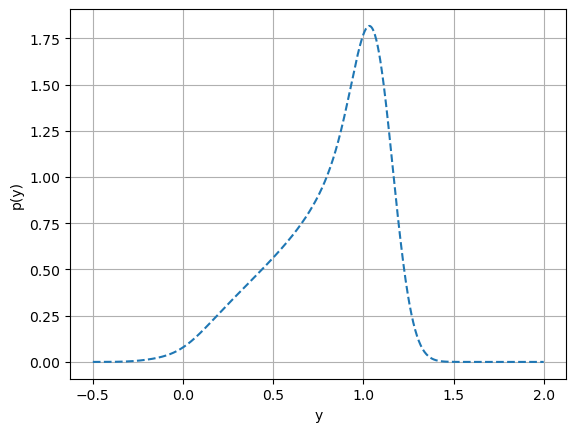

In [ ]:
# plt.plot(ys, p_vals, label='MC Likelihood')
x = np.linspace(-0.5, 2, 1000)
plt.plot(x, p_interp(x), label='Interpolated', linestyle='--')
plt.xlabel('y')
plt.ylabel('p(y)')
plt.grid()

### Build density from y samples? (fast to build, but slow to evaluate)

- generate y samples
- build density from the samples (e.g., kernel density estimation, histogram, etc.)

✅ Pros:

- very flexible
- works perfectly with black-box g
- reusable

❌ Cons:

- KDE smoothing error

In [ ]:
def sample_y(g, alpha, beta_param, sigma, N=100000):
    x = np.random.beta(alpha, beta_param, size=N)
    noise = np.random.normal(0, sigma, size=N)
    y = np.array([g(xi) for xi in x]) + noise
    return y

In [ ]:
from scipy.stats import gaussian_kde

y_samples = sample_y(g, alpha, beta, sigma, N=100000)
kde = gaussian_kde(y_samples)

kde(0.2)  # estimate p(y)

array([0.26202133])

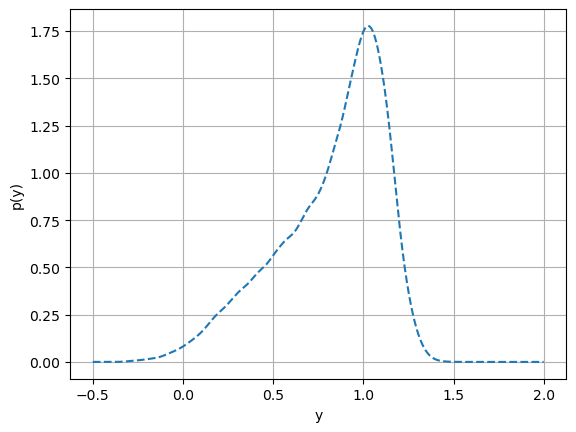

In [ ]:
# plt.plot(ys, p_vals, label='MC Likelihood')
x = np.linspace(-0.5, 2, 1000)
plt.plot(x, kde(x), label='Interpolated', linestyle='--')
plt.xlabel('y')
plt.ylabel('p(y)')
plt.grid()

### Mixture approximation (simple and precise, but slow to evaluate)

::: {.callout-note title="Note"}
- This is what i have done with MC sampling earlier
:::

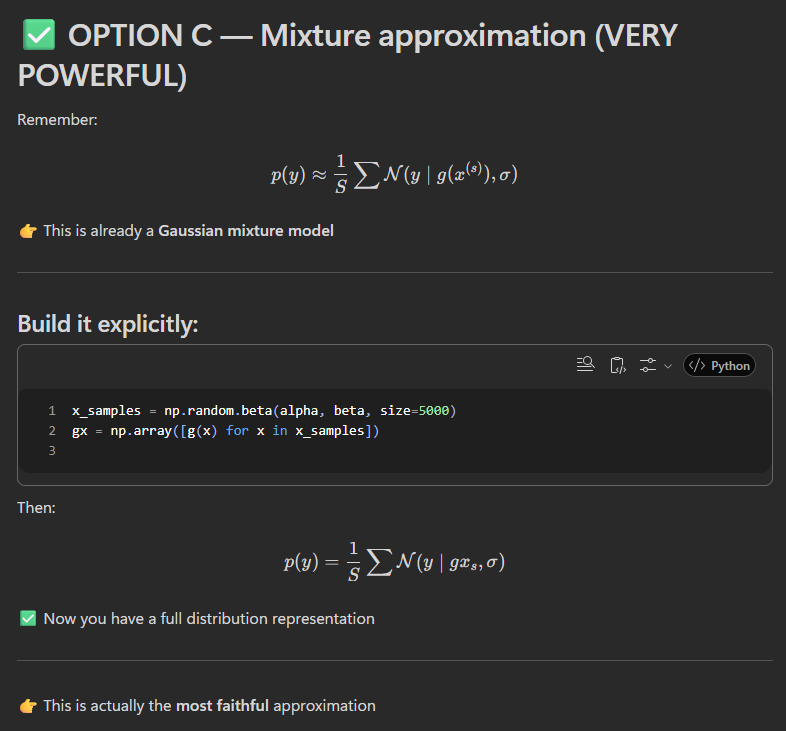

In [ ]:
import numpy as np

def build_gmm(g, alpha, beta_param, sigma, S=5000, seed=42):
    rng = np.random.default_rng(seed)
    
    # Sample latent variable
    x_samples = rng.beta(alpha, beta_param, size=S)
    
    # Pass through black-box function
    gx = np.array([g(x) for x in x_samples])
    
    # Store mixture components
    return {
        "means": gx,           # μ_s = g(x_s)
        "sigma": sigma         # same variance for all
    }


In [ ]:
from scipy.stats import norm

def gmm_pdf(y, gmm):
    means = gmm["means"]
    sigma = gmm["sigma"]
    
    return np.mean(norm.pdf(y, loc=means, scale=sigma))

def gmm_logpdf(y, gmm):
    means = gmm["means"]
    sigma = gmm["sigma"]
    
    log_vals = norm.logpdf(y, loc=means, scale=sigma)
    
    m = np.max(log_vals)
    return m + np.log(np.mean(np.exp(log_vals - m)))


In [ ]:
# def g(x):
#     return np.sin(5*x) + x**2

# alpha, beta_param = 2.0, 5.0
# sigma = 0.1

# Build mixture once
gmm = build_gmm(g, alpha, beta, sigma, S=10**2)
print(f"gmm means (first 5): {gmm['means'][:5]}")
print(f"gmm sigma: {gmm['sigma']}")

# Evaluate many times cheaply
print(gmm_pdf(0.2, gmm))
print(gmm_pdf(0.5, gmm))
print(gmm_logpdf(0.2, gmm))

gmm means (first 5): [0.99853527 1.06938808 1.0807676  1.08618348 1.04235609]
gmm sigma: 0.1
0.25533954910148426
0.5360727031316584
-1.3651610544664652


In [ ]:
gmm['means'].shape

(100,)

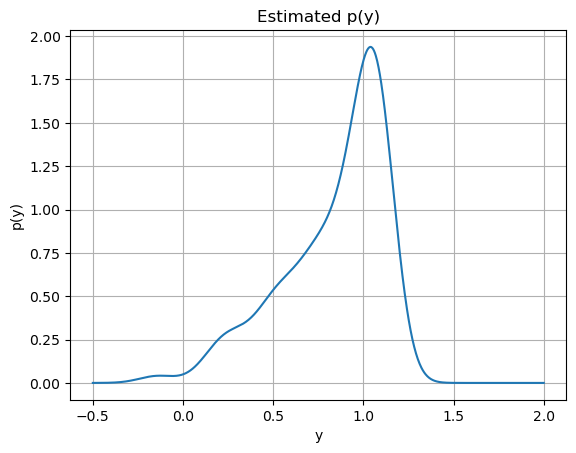

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-0.5, 2, 1000)
vals = [gmm_pdf(y, gmm) for y in x]

plt.plot(x, vals)
plt.title("Estimated p(y)")
plt.xlabel('y')
plt.ylabel('p(y)')
plt.grid()
plt.show()


### Surrogate model of g(x)

1. Approximate g(x) with a smooth model
2. Use fast integration afterward

# case study Overview

::: {.content-hidden}
## Goal of this Cass study

::: {.incremental}
- Setup an new stochastic model
- Evaluate the Bayes risk whit the new stochastic model
- Try out new decision rules
- Implement importance sampling in MCS
:::
:::

## Chosen Features

Modal properties: 

- x first natural frequencies
- x first mode shapes


Features: 

- natural frequencies
- Total Modal Assurance Criterion (TMAC)
  - $MAC(\phi_a,\phi_b)=\frac{|\phi_a^T\phi_b|^2}{(\phi_a^T\phi_a)(\phi_b^T\phi_b)}$
  - with no damage as reference $H_0$
- Modal Flexibility
  - $F = \sum_{i=1}^{n} \frac{\phi_i \phi_i^T}{\omega_i^2}$




## Evaluation of the Bayes risk

Numarical integration: 

- MCS with importance sampling 

Decision rules:

- Explicit likelihood for Modal properties (no use of features)
    - Maximum a posteriori (MAP) decision rule $\delta(y) = \arg\max_{a} p(H \mid y)$
- Supervised Machine learning (ML) classification based on the features (no use of likelihood)
    - Logistic regression

## Prior distibution

::: {.notes}
I have chosen to use uniformed priors for the damage states? 
:::

In [ ]:
#| echo: fallse
#| output: true
H_1 = 0.01
H_0 = 1-H_1

# uninformed prior
N_prior = 2**4
prior_H = np.array([H_0, H_1])
prior_theta = np.concatenate(([H_0], np.repeat(H_1 / (N_prior - 1), N_prior - 1)))

print(f"Prior probabilities for H: {prior_H}")
print(f"\nPrior probabilities for θ: {np.round(prior_theta, 4)}")

Prior probabilities for H: [0.99 0.01]

Prior probabilities for θ: [9.9e-01 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04
 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04]


## Cost function

::: {.nonincremental}
::: panel-tabset
### Total Cost

$$
C_\text{total} = C_\text{prediction}(H, d) + C_\text{sensors}(e)
$$

### Sensor Cost's 

$$
C_\text{sensors}(e) = 5 + 1 \cdot \text{number of sensors}
$$

### Prediction Cost Matrix

$$
C_\text{prediction} = \begin{bmatrix}
0 & 50 \\
10000 & 10
\end{bmatrix} = 
\begin{bmatrix}
\text{True Negative} & \text{False Positive} \\
\text{False Negative} & \text{True Positive}
\end{bmatrix}
$$

where:

- Positive: is the prediction of damage.
- Negative: is the prediction of no damage.
- True Positive (TP): Correctly predicting damage when it is present.
- False Positive (FP): Incorrectly predicting damage when it is not present.
- True Negative (TN): Correctly predicting no damage when it is not present.
- False Negative (FN): Incorrectly predicting no damage when there is actually damage.


### code


In [ ]:
#| echo: true
#| output: true
# C [H, d] = the prediction cost
prediction_cost = np.array([[0,   50],  # TN, FP
                            [10000, 100]   # FN, TP
                            ])  

H = 1; d = 1 
print(f"Prediction cost: {prediction_cost[H, d]}, which is the cost of predicting {d} when the true state is {H}.")

def sensor_cost(n_sensors):
    return 5 + 1 * n_sensors

Prediction cost: 100, which is the cost of predicting 1 when the true state is 1.


:::
:::

::: {.content-hidden}
# Running the document 
:::

In [ ]:
#| echo: false
#| output: false
#-- åben pdf
import os
def open_pdf(file_path):
    try:
        os.startfile(file_path)
        print("PDF-filen er åbnet.")
    except Exception as e:
        print(f"Der opstod en fejl: {e}")
def close_adobe_acrobat():
    os.system("taskkill /f /im Acrobat.exe")  # Luk Adobe Acrobat Reader
#-- hent filnaven
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
notebook_name = os.path.splitext(os.path.basename(path))[0]
#-- test count
countPDF = 0; countHTML = 0;countGitHub = 0
countPDF = 0; countHTML = 1;countGitHub = 0
countPDF = 0; countHTML = 1;countGitHub = 1

In [ ]:
#| echo: false
#| output: false
# countPDF += 1
# if countPDF > 1: #!quarto render notebook_name.ipynb --to pdf
#   os.system(f"quarto render {notebook_name}.ipynb --to beamer")
#   #open_pdf(f"{notebook_name}.pdf")
#   os.system(f"start {notebook_name}.pdf")

In [ ]:
#| echo: false
#| output: false
# quarto render P_new.ipynb --to revealjs --output P_new.html
countHTML += 1
if countHTML > 1: #!quarto render notebook_name.ipynb --to html
  os.system(f"quarto render {notebook_name}.ipynb --to revealjs --output {notebook_name}.html")
  os.system(f"start {notebook_name}.html")

In [ ]:
#| echo: false 
#| output: false
# save an copy notebook_name.html in the "research-notebook" folder and rename it "index.html"ArithmeticError
countGitHub += 1
if countGitHub > 1:
  from quarto_files.git_add import git_add_and_push
  # add index.html to git and push to GitHub
  git_add_and_push(notebook_name, output_name="P_new",  type="html")
  # add Readme.md to git and push to GitHub
#   git_add_and_push("Readme", type="md")
  


Current directory: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester
✅ Source file exists: P_new2.html
File size: 5832817 bytes
✅ Destination directory exists: research-notebook
Files in destination: ['.git', 'index.html', 'P_new.html', 'README.md', 'Theory Of The Model.md', 'week_16', 'week_17', 'week_18']
Copy command output:         1 file(s) copied.

Copy command errors: 
Copy command return code: 0
✅ File successfully copied to research-notebook\P_new.html

Changed to directory: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester\research-notebook
❌ Git operation failed: [WinError 2] The system cannot find the file specified

Returned to: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester
